In [1]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from matplotlib import colormaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import binned_statistic, binned_statistic_2d, gaussian_kde
from scipy.signal import find_peaks
from scipy.optimize import minimize
from scipy import linalg
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as galac
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

from cmcrameri.cm import batlow

import stream_dataset as sd
import GC
import agama_stream as ags

In [2]:
plt.rcParams['font.sans-serif'] = ['helvetica', 'DejaVu Sans',
                               'Lucida Grande', 'Verdana']

In [3]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '/Users/ybchen/Documents/GC_stream/notebooks/../GC_stream/agama_stream.py'>

In [4]:
def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

**download and select isochrones**

In [5]:
# download isochrone

feh_list = np.array([-1.9, -1.5, -1.3, -1.1, -0.7])
Z_list = 10.0**feh_list*0.0152

# download gaia isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='gaia') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_gaia/feh%g.csv'%feh_list[i])

# download cfht isochrone
# iso_list = [parsec.get_one_isochrone(1.25e10,Z,model='parsec12s_r14',phot='megacam_wircam') for Z in Z_list]
# for i in range(len(feh_list)):
#     iso_list[i].to_pandas().to_csv('../data/iso_cfht/feh%g.csv'%feh_list[i])

In [6]:
# load isochrone

iso_gaia_list = []
for i in range(len(feh_list)):
    iso_gaia_list.append(pd.read_csv('../data/iso_gaia/feh%g.csv'%feh_list[i]))
    
iso_cfht_list = []
for i in range(len(feh_list)):
    iso_cfht_list.append(pd.read_csv('../data/iso_cfht/feh%g.csv'%feh_list[i]))

In [7]:
# select isochrone

def select_iso(color, mag, iso_list, color1_key, color2_key, mag_key):
    
    comp = np.inf
    idx = np.nan
    
    for j in range(len(iso_list)):
        iso = iso_list[j]
        iso_color1 = iso[color1_key]
        iso_color2 = iso[color2_key]
        iso_mag = iso[mag_key]
        
        mask = iso['label'] <= 3
        iso_color = iso_color1[mask][::-1]-iso_color2[mask][::-1]
        iso_mag = iso_mag[mask][::-1]

        dcolor = color - np.interp(mag, iso_mag, iso_color)
        dcolor = np.mean(dcolor**2)
        if dcolor < comp:
            comp = dcolor
            idx = j

    return idx

def calc_mass(mag, iso, mag_key):
    iso_mag = iso[mag_key]
    iso_Mini = iso['Mini']
    
    mask = iso['label'] <= 3
    iso_mag = iso_mag[mask][::-1]
    iso_Mini = iso_Mini[mask][::-1]
    return np.interp(mag, iso_mag, iso_Mini)

**name converter**

In [8]:
def display_name_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        )
    
def display_name_simple_convert(name):
    return (name
        .replace('_', ' ')
        .replace('NGC 4590', 'M68')
        .replace('NGC 5139', r'$\omega$Cen')
        .replace('NGC 6341', 'M92')
        .replace('NGC 5904', 'M5')
        .replace('NGC ', 'N')
        )

**detect segments from streams**

In [9]:
def detect_segs(stream, width=None, gap_angle=10, percentiles=[10,90], min_count=10):
    angle_tid = stream.prog['rt'] / stream.prog['Rsun'] * 1e-3 * 180 / np.pi
    if width is None:
        width = np.sqrt(np.mean(stream.phi2hat**2))
    segs = []
    if stream.prog_phi2hat < width and stream.prog_phi2hat > -width:
        maskl = (stream.phi1 < stream.prog_phi1 - angle_tid) 
        maskr = (stream.phi1 > stream.prog_phi1 + angle_tid)
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskl]), gap_angle, percentiles, min_count))
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1[maskr]), gap_angle, percentiles, min_count))
    else:
        segs.extend(detect_gaps_in_arms(np.sort(stream.phi1), gap_angle, percentiles, min_count))
    return segs

def detect_gaps_in_arms(phi1_arm, gap_angle=10, percentiles=[10,90], min_count=10):
    cuts = [-np.inf]
    for i in range(len(phi1_arm)-1):
        if phi1_arm[i+1] - phi1_arm[i] >= gap_angle:
            cuts.append((phi1_arm[i+1] + phi1_arm[i])/2)
    cuts.append(np.inf)
    
    segs = []
    for i in range(len(cuts)-1):
        mask = (phi1_arm > cuts[i]) & (phi1_arm <= cuts[i+1])
        if len(phi1_arm[mask]) < 10:
            continue
        seg = np.percentile(phi1_arm[mask], percentiles)
        segs.append(seg)
        if len(phi1_arm[mask]) < min_count:
            continue
    return segs

**calculate Gaussian width for segments**

In [10]:
def calc_selection_function(stream, segs):
    gaussian_widths = []
    for seg in segs:
        mask = (stream.phi1 > seg[0]) & (stream.phi1 <= seg[1])
        gaussian_widths.append(calc_gaussian_width_seg(stream.phi2hat[mask]))
    return gaussian_widths

def calc_gaussian_width_seg(seg_phi2hat):
    return np.sqrt(np.mean(seg_phi2hat**2))

**mass function**

In [11]:
def kroupa(mmin, mmax):
    # for 0.5 < mmax < 1 and 0.08 < mmin < 1
    if mmin == 0:
        return -0.676877 * mmax**-0.3 + 1.19048
    if mmin < 0.5:
        return -0.676877 * mmax**-0.3 - 0.580180 * mmin**0.7 + 1.19048
    else:
        return -0.676877 * (mmax**-0.3 - mmin**-0.3)
kroupa = np.vectorize(kroupa)

def power_law_imf(mmin, mmax, slope):
    if np.abs(slope + 2) < 0.0001:
        return np.log(mmax) - np.log(mmin)
    return (mmax**(2+slope) - mmin**(2+slope)) / (2+slope)
    
def power_law_broken_imf(mmin, mmax, slope):
    if mmin < 0.08:
        if np.abs(slope + 2) < 0.0001:
            return np.log(mmax) - np.log(0.08) + (0.08**2 - mmin**2) * 0.08**slope / 2
        return (mmax**(2+slope) - 0.08**(2+slope)) / (2+slope) + (0.08**2 - mmin**2) * 0.08**slope / 2 
    return power_law_imf(mmin, mmax, slope)
power_law_broken_imf = np.vectorize(power_law_broken_imf)

def power_law_baumgardt_imf(mmin, mmax, alow, ahigh):
    # assume mmin < 0.4 and mmax > 0.4
    if mmin >= 0.4:
        return 0.4**(alow-ahigh) * (mmax**(2+ahigh)-mmin**(2+ahigh)) / (2+ahigh)
    if mmax <= 0.4:
        return (mmax**(2+alow)-mmin**(2+alow)) / (2+alow)
    return 0.4**(alow-ahigh) * (mmax**(2+ahigh)-0.4**(2+ahigh)) / (2+ahigh) + (0.4**(2+alow)-mmin**(2+alow)) / (2+alow)
power_law_baumgardt_imf = np.vectorize(power_law_baumgardt_imf)

In [12]:
power_law_imf(0.08,1,-1.5) / power_law_imf(0.08,1,-1-1.5)

0.282842712474619

### Load stream data

**load GC data**

In [13]:
# load GC info as pandas dataframe
gc = GC.load_GC()

# use Koposov+17 for Pal 5
gc.at['Pal_5', 'RA'] = 229
gc.at['Pal_5', 'DEC'] = -0.111
gc.at['Pal_5', 'Rsun'] = 23.6 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'R_Sun'] = 23.6 # hilker: 21.94, Koposov: 23.6
gc.at['Pal_5', 'mu_alpha'] = -2.23
gc.at['Pal_5', 'mu_delta'] = -2.22
gc.at['Pal_5', '<RV>'] = -58.51 # hilker: 58.51, Koposov: 57.4

In [14]:
# Baumgardt et al. 2023 broken power-law, split at 0.4 Msun

alow = {
    'NGC_3201':-0.86 , 'NGC_4590':-1.01 , 'NGC_5139':-0.28 , 'Pal_5':-0.39 , 'NGC_6341':-0.41 , 'NGC_6397':-0.43 ,
    'NGC_288':-0.51 , 'NGC_1851':-0.52 , 'NGC_2298':+0.31 , 'NGC_2808':-0.27 , 'NGC_5904':-0.50 , 'NGC_6101':-0.38,
}

ahigh = {
    'NGC_3201': -1.51, 'NGC_4590':-1.72 , 'NGC_5139':-1.61 , 'Pal_5':-0.96 , 'NGC_6341':-1.35 , 'NGC_6397':-0.92 ,
    'NGC_288':-0.98 , 'NGC_1851':-0.91 , 'NGC_2298':-0.07 , 'NGC_2808':-1.19 , 'NGC_5904':-1.22 , 'NGC_6101':-1.88, 
}

**load Ibata+24**

In [15]:
G_limit = 19

In [149]:
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67], dtype=int)

gc_stream_list = ['Pal_5'] # test case
gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

1it [00:02,  2.36s/it]


**load Ibata+19**

In [17]:
r_limit = 22

# load Ibata+19
hdul = fits.open('../data/pal_5_cfht_ibata17.fit')
data = hdul[1].data
hdul.close()

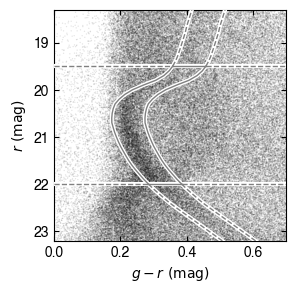

In [18]:
fig, ax0 = plt.subplots(1, 1, figsize=(3,3), sharex=True, sharey=True)
# ax0.hist2d(data['g0mag']-data['r0mag'], data['r0mag'], bins=(np.arange(0,0.81,0.01), np.arange(16,24.1,0.1)))#, norm=mpl.colors.LogNorm())
ax0.scatter(data['g0mag']-data['r0mag'], data['r0mag'], s=1, fc='k', ec='none', alpha=0.1, rasterized=True)

# set CMD mask
iso = iso_cfht_list[2]
mask = iso['label'] <= 3
x = iso["g'mag"][mask]-iso["r'mag"][mask]
y = iso["r'mag"][mask]+16.6
interp = interp1d(y, x, bounds_error=False, fill_value=999)

color_width = 0.05

# mask
c = 'gray'
lw = 1
yplot = np.arange(19.5,22.01,0.1)
xplot = interp(yplot)
ax0.plot(xplot+color_width, yplot, c=c, lw=lw, zorder=100)
ax0.plot(xplot-color_width, yplot, c=c, lw=lw, zorder=100)
ax0.plot([xplot[0]-color_width, xplot[0]+color_width], [yplot[0], yplot[0]], c=c, lw=lw, zorder=100)
ax0.plot([xplot[-1]-color_width, xplot[-1]+color_width], [yplot[-1], yplot[-1]], c=c, lw=lw, zorder=100)

# out
ax0.plot([0, xplot[0]-color_width], [yplot[0], yplot[0]], c=c, lw=lw, ls='--', zorder=100)
ax0.plot([0, xplot[-1]-color_width], [yplot[-1], yplot[-1]], c=c, lw=lw, ls='--', zorder=100)
ax0.plot([xplot[0]+color_width, 0.8], [yplot[0], yplot[0]], c=c, lw=lw, ls='--', zorder=100)
ax0.plot([xplot[-1]+color_width, 0.8], [yplot[-1], yplot[-1]], c=c, lw=lw, ls='--', zorder=100)

yplot = np.arange(22,24.01,0.05)
xplot = interp(yplot)
ax0.plot(xplot+color_width, yplot, c=c, lw=lw, ls='--', zorder=100)
ax0.plot(xplot-color_width, yplot, c=c, lw=lw, ls='--', zorder=100)

yplot = np.arange(16,19.51,0.1)
xplot = interp(yplot)
ax0.plot(xplot+color_width, yplot, c=c, lw=lw, ls='--', zorder=100)
ax0.plot(xplot-color_width, yplot, c=c, lw=lw, ls='--', zorder=100)

# bg
yplot = np.arange(16,24.01,0.1)
xplot = interp(yplot)
ax0.plot(xplot+color_width, yplot, c='w', lw=3*lw, zorder=99)
ax0.plot(xplot-color_width, yplot, c='w', lw=3*lw, zorder=99)
ax0.plot([0,0.8], [19.5, 19.5], c='w', lw=3*lw, zorder=99)
ax0.plot([0,0.8], [22, 22], c='w', lw=3*lw, zorder=99)

ax0.set_xlim(0, 0.7)
ax0.set_ylim(23.2, 18.3)
ax0.set_xlabel(r'$g-r\ ({\rm mag})$')
ax0.set_ylabel(r'$r\ ({\rm mag})$')
ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/cfht_cmd.pdf', dpi=300, bbox_inches ='tight')
plt.show()

In [19]:
# apply CMD mask
mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])-color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

ds_i19 = {}
ds_i19['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

# Now, the background
mask = (data['g0mag']-data['r0mag'] > interp(data['r0mag'])+color_width)
mask &= (data['g0mag']-data['r0mag'] < interp(data['r0mag'])+3*color_width)
mask &= (data['r0mag'] < r_limit)
mask &= (data['r0mag'] > 19.5)

ds_i19_bg = {}
ds_i19_bg['Pal_5'] = sd.StreamDataset('Ibata+19', None, data['RAJ2000'][mask], data['DEJ2000'][mask], None, None, 
        None, data['r0mag'][mask], data['g0mag'][mask]-data['r0mag'][mask], None, None, None, None, None, gc.loc['Pal_5'])

In [20]:
ds_i19['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)
ds_i19_bg['Pal_5'].construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
ds_i19_bg['Pal_5'].construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [21]:
ds_i19['Pal_5'].apply_mask((ds_i19['Pal_5'].phi1<14) & (ds_i19['Pal_5'].phi1>-14))
ds_i19_bg['Pal_5'].apply_mask((ds_i19_bg['Pal_5'].phi1<14) & (ds_i19_bg['Pal_5'].phi1>-14))

In [151]:
# load Ibata+24
dtype = {
    'names':   ('star_id', 'ra', 'dec', 'plx', 'mu_ra', 'mu_dec', 'G',  'BP-RP', 'vr', 'evr', 'rvr', 'stream_id'),
    'formats': ('i8',      'f8', 'f8',  'f8',  'f8',    'f8',     'f8', 'f8',    'f8', 'f8',  'i8' , 'i8'       )}

ds = np.loadtxt('../data/apjad382dt1_mrt.txt', dtype=dtype, skiprows=54)

gc_stream_list = ['NGC_3201', 'NGC_4590', 'NGC_5139', 'Pal_5', 'NGC_6341', 'NGC_6397',
    'NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5904', 'NGC_6101', 
    'NGC_1261', 'NGC_5466', 'NGC_7099', 'NGC_7089']
gc_stream_ids = np.array([34, 47, 54, 61, 68, 69,
    3, 16, 23, 26, 62, 67, 
    12, 57, 77, 76], dtype=int)

gc_stream_list = ['NGC_288', 'NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_3201', 'NGC_4590',
    'NGC_5139', 'Pal_5', 'NGC_5904', 'NGC_6101', 'NGC_6341', 'NGC_6397'] # remove 7089: too few stars; remove 1261, 5466, 7099: can't fit
gc_stream_ids = np.array([3, 16, 23, 26, 34, 47, 
    54, 61, 62, 67, 68, 69], dtype=int)
color_list = ['k', 'r', 'b', 'gray', 'g', 'm', 'c', 'pink', 'orange', 'brown', 'khaki', 'tan']
# mf_slope_list = [-0.75, -0.74, -0.05, 'NGC_2808', -1.22, -1.25,
#     'NGC_5139', 'Pal_5', -0.81, -1.24, -0.77, -0.40]
# mf_dslope_list = [0.3, 0.3, 0.3, 'NGC_2808', 0.3, 0.3,
#     'NGC_5139', 'Pal_5', 0.3, 0.3, 0.3, 0.3]
# mf_slope_ref_list = ['Ebrahimi+20', 'Ebrahimi+20', 'Ebrahimi+20', 'NGC_2808', 'Ebrahimi+20', 'Ebrahimi+20',
#     'NGC_5139', 'Pal_5', 'Ebrahimi+20', 'Ebrahimi+20', 'Ebrahimi+20', 'Sollima&Baumgardt17']

# gc_stream_list = ['Pal_5'] # test case
# gc_stream_ids = np.array([61], dtype=int)

ds_i24 = {}
for i, name in tqdm(zip(gc_stream_ids, gc_stream_list)):
    d = ds[ds['stream_id'] == i]
    ds_i24[name] = sd.StreamDataset('Ibata+24', d['star_id'], d['ra'], d['dec'], d['plx'], d['mu_ra'], 
        d['mu_dec'], d['G'], d['BP-RP'], None, d['vr'], d['evr'], d['rvr'], d['stream_id'], gc.loc[name])
    ds_i24[name].cut_mag(G_limit)
    ds_i24[name].construct_greatcircle()
    ds_i24[name].construct_greatcircle_coord()
    ds_i24[name].construct_polynomial_coord(deg=4)

12it [00:37,  3.11s/it]


In [25]:

import numpy as np

import astropy.coordinates as coord
from astropy.coordinates.matrix_utilities import matrix_transpose

mat = np.array([
    [ 0.85786144,  0.18693242, -0.47867527],
    [ 0.48014833,  0.04034979,  0.8762588 ],
    [ 0.18311562, -0.98154377, -0.05514076]])

class GreatCircle(coord.BaseCoordinateFrame):
    default_representation = coord.SphericalRepresentation
    default_differential = coord.SphericalCosLatDifferential

    frame_specific_representation_info = {
        coord.SphericalRepresentation: [
            coord.RepresentationMapping('lon', 'phi1'),
            coord.RepresentationMapping('lat', 'phi2'),
            coord.RepresentationMapping('distance', 'distance'),
        ]
    }

@coord.frame_transform_graph.transform(coord.StaticMatrixTransform, coord.ICRS, GreatCircle)
def icrs_to_GreatCircle():
    return mat

@coord.frame_transform_graph.transform(coord.StaticMatrixTransform, GreatCircle, coord.ICRS)
def GreatCircle_to_icrs():
    return matrix_transpose(mat)

In [152]:
# generate mock stream

pot_agama = agama.Potential("../data/MWPotential2014.ini")

t_tot = 8000 * u.Myr
dt = 2 * u.Myr
release_type = 'uniform'
# release_type = 'peri_only'
n_steps = (t_tot/dt).value.astype(int)
nhalf = n_steps
assert nhalf % n_steps == 0

mockstreams = {}
T_dict = {}

# for key in ['Pal_5']:
for key in gc_stream_list:
    stream = ds_i24[key]
    
    gc_mass = 10**stream.prog['logm']
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
    
    assert np.sum(nhalf_release) == nhalf
    
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())
    
    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)
    
    mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
    mockstream.construct_polynomial_coord(p=stream.p, deg=4)
    mockstream.set_release_time(time_stream)
    mockstreams[key] = mockstream

7998 orbits complete (1204 orbits/s)
7998 orbits complete (1600 orbits/s)
7998 orbits complete (1323 orbits/s)
7998 orbits complete (1062 orbits/s)
7998 orbits complete (4166 orbits/s)
7998 orbits complete (4268 orbits/s)
7998 orbits complete (696.9 orbits/s)
7998 orbits complete (2366 orbits/s)
7998 orbits complete (2815 orbits/s)
7998 orbits complete (5903 orbits/s)
7998 orbits complete (831.7 orbits/s)
7998 orbits complete (749.7 orbits/s)


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

import gala.potential as gp
import gala.dynamics as gd
from gala.dynamics import mockstream as ms
from gala.units import galactic

# key = 'NGC_288'

# pot = gp.BovyMWPotential2014(units=galactic)
# H = gp.Hamiltonian(pot)

# prog_w0 = gd.PhaseSpacePosition(pos=[gc.loc[key]['X'], gc.loc[key]['Y'], gc.loc[key]['Z']] * u.kpc,
#                                 vel=[gc.loc[key]['U'], gc.loc[key]['V'], gc.loc[key]['W']] * u.km/u.s)
# prog_mass = 10**gc.loc[key]['logm'] * u.Msun


# # Chen+24 (with prog.)
# df = ms.ChenStreamDF()
# prog_pot = gp.PlummerPotential(m=prog_mass, b=4*u.pc, units=galactic)
# gen = ms.MockStreamGenerator(df, H, progenitor_potential=prog_pot)
# %time stream_c24b, prog_c24b = gen.run(prog_w0, prog_mass, dt=-6*u.Myr, n_steps=500, output_every=True, output_filename='/Users/ybchen/Downloads/NGC288stream/stream.h5', overwrite=True)

In [28]:
# import h5py

# cmap = colormaps['rainbow']

# with h5py.File('/Users/ybchen/Downloads/NGC288stream/stream.h5') as d:
#     ps_prog = d['nbody']['pos'][:,:,0]
#     ps_s = d['stream']['pos'][:]
#     t_s = d['stream']['time'][:]

# for i in tqdm(range(len(ps_prog[0]))):
# # for i in [-1]:
#     p_prog = ps_prog[:,i]
#     p_s = ps_s[:,i,:]

#     fig, ax0 = plt.subplots(1, 1, figsize=(4,4), sharex=True, sharey=True)
#     ax0.plot(ps_prog[1,:i+1], ps_prog[0,:i+1], lw=0.5, c='k', alpha=0.3)
#     ax0.scatter(p_prog[1], p_prog[0], s=10, marker='*', alpha=1, fc='k', ec='none')
#     ax0.scatter(0, 0, s=10, fc='r', ec='none', alpha=1)
#     ax0.scatter(p_s[1,:], p_s[0,:], s=1, alpha=0.5, fc=cmap(t_s.repeat(2)/np.min(t_s)), ec='none')
#     ax0.set_xlim(15,-15)
#     ax0.set_ylim(15,-15)
#     ax0.set_xlabel(r'Y (kpc)')
#     ax0.set_ylabel(r'X (kpc)')
#     plt.gca().set_aspect('equal')
#     plt.savefig('/Users/ybchen/Downloads/NGC288stream/snap%d.png'%i, dpi=500, bbox_inches ='tight')
#     plt.close(fig)

In [29]:
# # make movie

# total_frames = len(ps_prog[0])
# fps = 30
# duration = total_frames / fps

# import ffmpeg
# (
#     ffmpeg
#     .input('/Users/ybchen/Downloads/NGC288stream/snap%d.png', framerate=fps)
#     .filter('fps', fps=fps, round='up')
#     .output('/Users/ybchen/Downloads/NGC288stream/movie.mp4', r=fps, t=duration, pix_fmt='yuv420p')
#     .run()
# )

In [30]:
print('alpha = 0, mass below 0.08 Msun: %.1f%%'%(100 * power_law_broken_imf(0, 0.08, -0) / power_law_broken_imf(0, 0.8, -0)))
print('alpha = 1, mass below 0.08 Msun: %.1f%%'%(100 * power_law_broken_imf(0, 0.08, -1) / power_law_broken_imf(0, 0.8, -1)))

alpha = 0, mass below 0.08 Msun: 1.0%
alpha = 1, mass below 0.08 Msun: 5.3%


**determine segment range**


NGC_288 NGC 288
1.003606634788374

NGC_1851 NGC 1851
0.668451270032993

NGC_2298 NGC 2298
0.36286082435955297

NGC_2808 NGC 2808
0.5702366080478893

NGC_3201 NGC 3201
0.8096911626381

NGC_4590 M68
1.3587903990980181

NGC_5139 $\omega$Cen
2.341534464059033

Pal_5 Pal 5
0.2405034036129333

NGC_5904 M5
0.36437896290750393

NGC_6101 NGC 6101
0.246568257302482

NGC_6341 M92
0.9439062874793678

NGC_6397 NGC 6397
1.1244788257594698


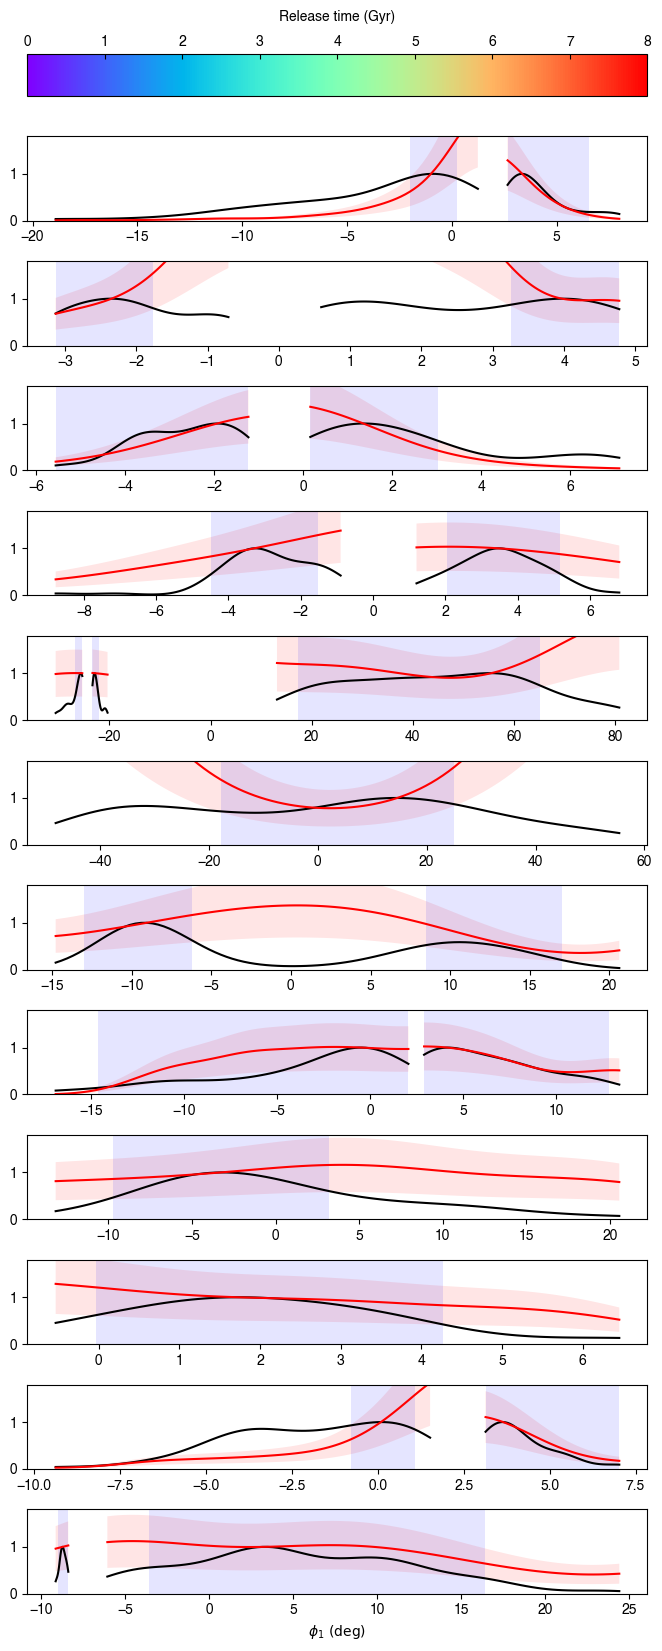

In [31]:
segs_dict = {}
widths_dict = {}
mockwidths_dict = {}

fig = plt.figure(figsize=(8, 20))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

cmap = colormaps['rainbow']

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]

    segs = detect_segs(stream, percentiles=[0,100])
    mask_segs = np.zeros_like(stream.phi1, dtype=bool)
    for seg in segs:
        mask_segs |= ((stream.phi1>=seg[0]) & (stream.phi1<=seg[1]))
    width = np.sqrt(np.mean(stream.phi2hat[mask_segs]**2))
    print(width)
    widths_dict[key] = width
    
    mask_segs = np.zeros_like(mockstream.phi1, dtype=bool)
    for seg in segs:
        mask_segs |= ((mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1]))
    mockwidth = np.sqrt(np.mean(mockstream.phi2hat[mask_segs]**2))
    mockwidths_dict[key] = mockwidth

    segs_dict[key] = []

    for seg in segs:
        mask_seg = ((stream.phi1>=seg[0]) & (stream.phi1<=seg[1]))
        x = np.linspace(seg[0], seg[1], 100)
        kde = gaussian_kde(stream.phi1[mask_seg])
        y = kde(x)/np.max(kde(x))
        yerr = (1/np.sqrt(kde(x)*len(stream.phi1[mask_seg])))
        # ax0.plot(x, y, c='k')
        # ax0.fill_between(x, y*(1-yerr), y*(1+yerr), fc='k', ec='none', alpha=0.1)
        
        sorted_phi1 = np.sort(stream.phi1[mask_seg])
        cdf = np.arange(1, len(sorted_phi1) + 1) / len(sorted_phi1)
        # ax0.plot(sorted_phi1, cdf)
        
        y_spl = UnivariateSpline(x,kde(x),s=0,k=4)
        y_spl_1d = y_spl.derivative(n=1)
        # ax0.plot(x, y_spl_1d(x),c='r')
        
        select_weights = np.ones_like(mockstream.phi1)
        select_weights *= np.exp(0.5 * mockstream.phi2hat**2 * (mockwidth**-2 - width**-2))
        mask = np.ones_like(mockstream.phi1, dtype=bool)
        mask &= (np.abs(mockstream.phi2hat) < 3*width)
        kde_mock = gaussian_kde(mockstream.phi1[mask], weights=select_weights[mask])
        ymock = kde_mock(x)/np.max(kde_mock(x))
        # ax0.plot(x, ymock, c='r')

        yratio_spl = UnivariateSpline(x,kde(x)/kde_mock(x),s=0,k=4)
        yratio_spl_1d = yratio_spl.derivative(n=1)
        
        factor = 0.5
        idx_masked = np.argmax(y[y>factor*np.max(y)] / ymock[y>factor*np.max(y)])
        idx = np.arange(len(x), dtype=int)[y>factor*np.max(y)][idx_masked]
        # if idx == 0 or idx == len(x)-1 or (y[idx-1]/y[idx] - ymock[idx-1]/ymock[idx]) * (y[idx+1]/y[idx] - ymock[idx+1]/ymock[idx]) < 0:
        if True:
            # idx = 0
            idx_masked = np.argmin(np.abs(yratio_spl_1d(x[y>factor*np.max(y)])))
            idx = np.arange(len(x), dtype=int)[y>factor*np.max(y)][idx_masked]
            idx = np.argmax(y)
        y /= y[idx]
        ymock /= ymock[idx]
        norm = 1
        ax0.plot(x, y/norm, c='k')
        # ax0.fill_between(x, y*(1-yerr), y*(1+yerr), fc='k', ec='none', alpha=0.1)
        ax0.plot(x, ymock/norm, c='r')

        tor = 0.5
        ax0.fill_between(x, (1-tor)*ymock/norm, (1+tor)*ymock/norm, fc='r', ec='none', alpha=0.1)
        # ax0.fill_between(x, np.ones_like(x)*np.max(y), (1-tor)*np.ones_like(x)*np.max(y), fc='k', ec='none', alpha=0.1)

        mask = (y/ymock >= 1-tor) & (y/ymock <= 1+tor)
        # mask = (y/np.max(y) >= 1-tor) & (y/np.max(y) <= 1+tor)
        if key == 'NGC_6341':
            mask &= ((y >= 0.5*np.max(y)) | (x > 2.5))
        left = np.min(x[mask])
        right = np.max(x[mask])
        if key == 'NGC_5139':
            left1 = np.min(x[mask&(x<0)])
            left2 = np.min(x[mask&(x>=0)])
            right1 = np.max(x[mask&(x<0)])
            right2 = np.max(x[mask&(x>=0)])
            segs_dict[key].append([left1, right1])
            segs_dict[key].append([left2, right2])
            ax0.fill_between([left1, right1], 0, 2, fc='b', ec='none', alpha=0.1)
            ax0.fill_between([left2, right2], 0, 2, fc='b', ec='none', alpha=0.1)
        else:
            segs_dict[key].append([left, right])
            ax0.fill_between([left, right], 0, 2, fc='b', ec='none', alpha=0.1)

    # ax0.set_yscale('log')
    ax0.set_ylim(0, 1.8)

ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

plt.show()


NGC_288 NGC 288
1.003606634788374

NGC_2808 NGC 2808
0.5702366080478893


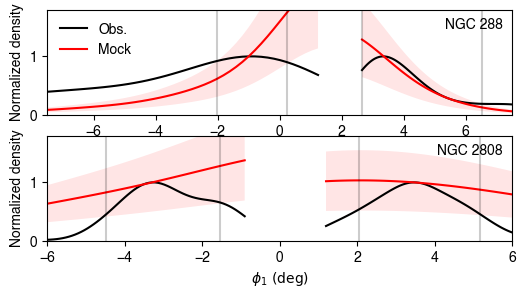

In [32]:
fig, axs = plt.subplots(2, 1, figsize=(6,3), sharey=True)
# plt.subplots_adjust(hspace=0.1)

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

for key, ax0 in zip(['NGC_288', 'NGC_2808'], axs):
# for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]

    segs = detect_segs(stream, percentiles=[0,100])
    mask_segs = np.zeros_like(stream.phi1, dtype=bool)
    for seg in segs:
        mask_segs |= ((stream.phi1>=seg[0]) & (stream.phi1<=seg[1]))
    width = np.sqrt(np.mean(stream.phi2hat[mask_segs]**2))
    print(width)
    
    mask_segs = np.zeros_like(mockstream.phi1, dtype=bool)
    for seg in segs:
        mask_segs |= ((mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1]))
    mockwidth = np.sqrt(np.mean(mockstream.phi2hat[mask_segs]**2))

    for seg in segs:
        mask_seg = ((stream.phi1>=seg[0]) & (stream.phi1<=seg[1]))
        x = np.linspace(seg[0], seg[1], 100)
        phi1_obs = stream.phi1[mask_seg]
        kde = gaussian_kde(phi1_obs)
        y = kde(x)/np.max(kde(x))
        yerr = (1/np.sqrt(kde(x)*len(stream.phi1[mask_seg])))
        # ax0.plot(x, y, c='k')
        # ax0.fill_between(x, y*(1-yerr), y*(1+yerr), fc='k', ec='none', alpha=0.1)
        
        sorted_phi1 = np.sort(stream.phi1[mask_seg])
        cdf = np.arange(1, len(sorted_phi1) + 1) / len(sorted_phi1)
        # ax0.plot(sorted_phi1, cdf)
        
        y_spl = UnivariateSpline(x,kde(x),s=0,k=4)
        y_spl_1d = y_spl.derivative(n=1)
        # ax0.plot(x, y_spl_1d(x),c='r')
        
        select_weights = np.ones_like(mockstream.phi1)
        select_weights *= np.exp(0.5 * mockstream.phi2hat**2 * (mockwidth**-2 - width**-2))
        mask = np.ones_like(mockstream.phi1, dtype=bool)
        mask &= (np.abs(mockstream.phi2hat) < 3*width)
        kde_mock = gaussian_kde(mockstream.phi1[mask], weights=select_weights[mask])
        ymock = kde_mock(x)/np.max(kde_mock(x))
        # ax0.plot(x, ymock, c='r')

        yratio_spl = UnivariateSpline(x,kde(x)/kde_mock(x),s=0,k=4)
        yratio_spl_1d = yratio_spl.derivative(n=1)
        
        factor = 0.5
        idx_masked = np.argmax(y[y>factor*np.max(y)] / ymock[y>factor*np.max(y)])
        idx = np.arange(len(x), dtype=int)[y>factor*np.max(y)][idx_masked]
        # if idx == 0 or idx == len(x)-1 or (y[idx-1]/y[idx] - ymock[idx-1]/ymock[idx]) * (y[idx+1]/y[idx] - ymock[idx+1]/ymock[idx]) < 0:
        if True:
            # idx = 0
            idx_masked = np.argmin(np.abs(yratio_spl_1d(x[y>factor*np.max(y)])))
            idx = np.arange(len(x), dtype=int)[y>factor*np.max(y)][idx_masked]
            idx = np.argmax(y)
        y /= y[idx]
        ymock /= ymock[idx]
        norm = 1
        ax0.plot(x, y/norm, c='k')
        # ax0.fill_between(x, y*(1-yerr), y*(1+yerr), fc='k', ec='none', alpha=0.1)
        ax0.plot(x, ymock/norm, c='r')

        tor = 0.5
        ax0.fill_between(x, (1-tor)*ymock/norm, (1+tor)*ymock/norm, fc='r', ec='none', alpha=0.1)
        # ax0.fill_between(x, np.ones_like(x)*np.max(y), (1-tor)*np.ones_like(x)*np.max(y), fc='k', ec='none', alpha=0.1)

        mask = (y/ymock >= 1-tor) & (y/ymock <= 1+tor)
        # mask = (y/np.max(y) >= 1-tor) & (y/np.max(y) <= 1+tor)
        if key == 'NGC_6341':
            mask &= ((y >= 0.5*np.max(y)) | (x > 2.5))
        left = np.min(x[mask])
        right = np.max(x[mask])
        if key == 'NGC_5139':
            left1 = np.min(x[mask&(x<0)])
            left2 = np.min(x[mask&(x>=0)])
            right1 = np.max(x[mask&(x<0)])
            right2 = np.max(x[mask&(x>=0)])
            ax0.vlines([left1, right1, left2, right2], 0, 1.8, color='k', alpha=0.2)
        else:
            ax0.vlines([left, right], 0, 1.8, color='k', alpha=0.2)
            
    ax0.text(0.98, 0.92, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='top', ha='right')

    # ax0.set_yscale('log')
    ax0.set_ylim(0, 1.8)
    ax0.set_ylabel(r'Normalized density')

axs[0].plot([], [], c='k', label='Obs.')
axs[0].plot([], [], c='r', label='Mock')
axs[0].legend(loc='upper left', frameon=False)
axs[0].set_xlim(-7.5,7.5)
axs[1].set_xlim(-6,6)
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/density_NGC_288.pdf', dpi=300, bbox_inches ='tight')
plt.show()

**age fit**


NGC_288 NGC 288
slope = 0.0
slope = 0.0

NGC_1851 NGC 1851
slope = 0.07320777755643952
slope = -0.07132053899579055

NGC_2298 NGC 2298
slope = -0.04741576661830968
slope = 0.053263641969900244

NGC_2808 NGC 2808
slope = -0.018288050597853


/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_1906/1890135374.py:10: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(sigi2) + (y-a-b*x)**2/sigi2)
/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_1906/1890135374.py:10: RuntimeWarning: divide by zero encountered in divide
  return np.sum(np.log(sigi2) + (y-a-b*x)**2/sigi2)
/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_1906/1890135374.py:10: RuntimeWarning: invalid value encountered in add
  return np.sum(np.log(sigi2) + (y-a-b*x)**2/sigi2)


slope = 0.023834910357826065

NGC_3201 NGC 3201
slope = -0.02508144206016394
slope = 0.01179756379624857

NGC_4590 M68
slope = -0.026328204235420673
slope = 0.05874433549424876

NGC_5139 $\omega$Cen
slope = 0.015216993041748368

Pal_5 Pal 5
slope = 0.3435671088999381
slope = -0.3662940100151525

NGC_5904 M5
slope = -0.016025895448047243

NGC_6101 NGC 6101
slope = -0.06424881581060336
slope = 0.059498979315356124

NGC_6341 M92
slope = 0.04219778514854183
slope = -0.03585962735472451

NGC_6397 NGC 6397
slope = 0.013536072734704791
slope = -0.006712128373614404


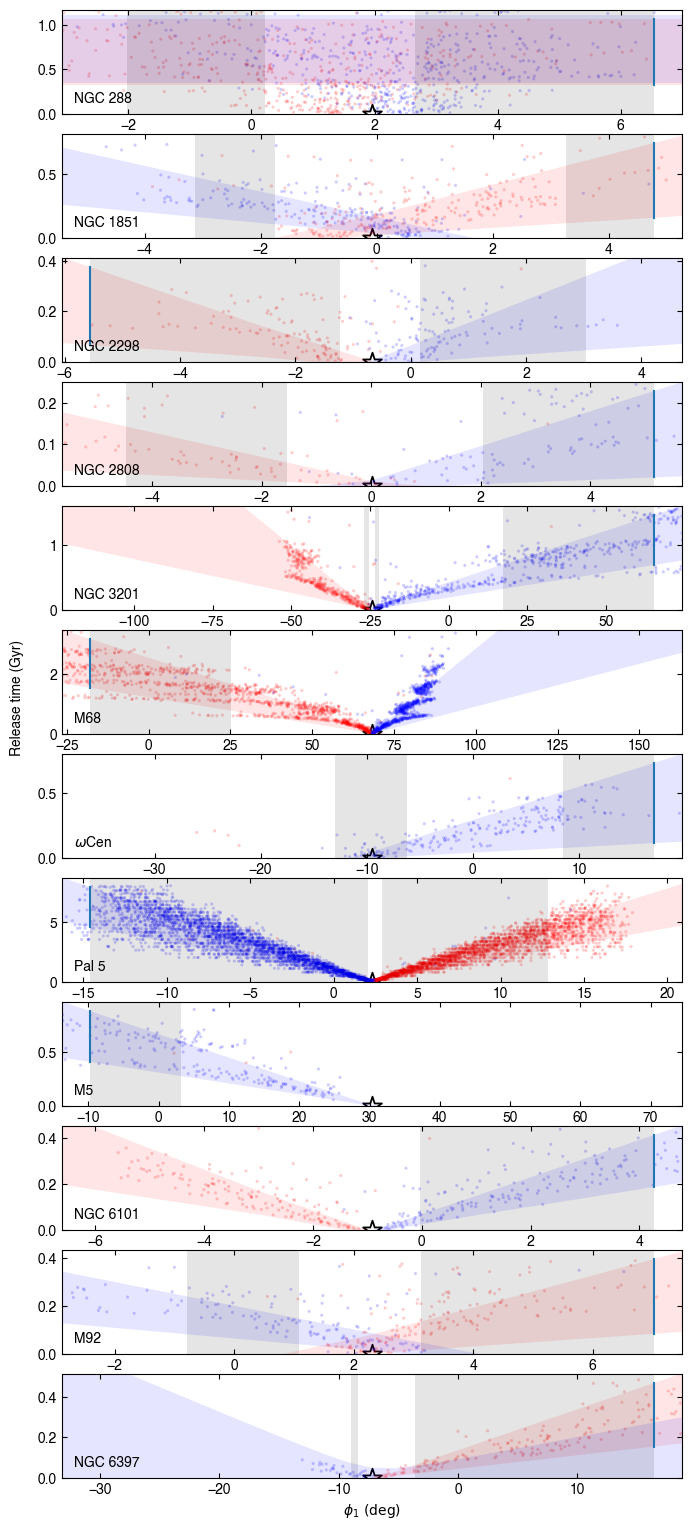

In [33]:
def neg_log_gaussian_likelihood(p, x, y, dx, dy):
    '''
    negative log of Gaussuan likelihood
    '''
    a = p[0]
    b = p[1]
    sig = p[2]
    sigy = p[3]
    sigi2 = (sig+sigy*y)**2 + dy**2 + (b*dx)**2
    return np.sum(np.log(sigi2) + (y-a-b*x)**2/sigi2)

def linear_fit_maxlike(x, y, dx, dy):
    bnds = ((None, None), (None, None), (0, None))
    o = minimize(neg_log_gaussian_likelihood, [1.,0.,1.], args=(x,y,dx,dy), bounds=bnds)
    return o.x

def linear_fit_maxlike_boot(x, y, dx, dy, size=100):
    data = np.column_stack((x, y, dx, dy))
    data_boot = data[np.random.randint(0, len(x), (size, len(x)))]
    
    a_list = np.zeros(size)
    b_list = np.zeros(size)
    sig_list = np.zeros(size)
    sigy_list = np.zeros(size)
    
    for i, d in enumerate(data_boot):
        bnds = ((None, None), (None, None), (0, None), (0, None))
        o = minimize(neg_log_gaussian_likelihood, [0.,0.,0.0001,0.0001], 
            args=(d[:,0],d[:,1],d[:,2],d[:,3]), bounds=bnds)
        a_list[i] = o.x[0]
        b_list[i] = o.x[1]
        sig_list[i] = o.x[2]
        sigy_list[i] = o.x[3]
        
    return a_list, b_list, sig_list, sigy_list

def plot_linear_fit_with_error(ax, xmin, xmax, xmean, ymean, a, da, b, db, sig, sigy, **kwargs):
    
    x = np.linspace(xmin, xmax, 100+1)
    y = a+b*(x-xmean)+ymean
    # dy = np.sqrt(sig**2 + da**2 + (db*(x-xmean))**2)
    dy = np.sqrt((sig+sigy*y)**2 + da**2 + (db*(x-xmean))**2)
    return ax.fill_between(x, (y-dy), (y+dy), **kwargs)



sep_width = False

dur_dict = {}
ddur_dict = {}
dphi1_max_dict = {}

fig = plt.figure(figsize=(8, 20))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.2)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]


# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['NGC_288'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    y = mockstream.phi2hat
    y = mockstream.d
    y = -mockstream.release_time*0.978
    # ax0.scatter(x, y, s=5, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    
    # plot observed stars and prog GC
    x_prog = stream.prog_phi1
    y_prog = 0
    ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.3)
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    
    # plot fitted curve
    mask_lead = np.ones_like(mockstream.phi1, dtype=bool)
    mask_lead[::2] = 0
    mask_trail = np.ones_like(mockstream.phi1, dtype=bool)
    mask_trail[1::2] = 0
    mask = np.ones_like(mockstream.phi1, dtype=bool)
    # mask &= (-mockstream.release_time*0.978 < t90_dict[key]) & (-mockstream.release_time*0.978 > t10_dict[key])
    mask &= (np.abs(mockstream.phi2hat) < 3*widths_dict[key])
    # mask &= (mockstream.phi1 <= np.max(segs_dict[key])) & (mockstream.phi1 >= np.min(segs_dict[key]))
    # mask &= mockstream.release_time < -0.1
    # if key in ['NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5139', 'NGC_6397'] :
    #     mask &= y < 0.5
    # else:
    #     mask &= y < t90_dict[key]
    ax0.scatter(x[mask_lead&mask], y[mask_lead&mask], s=5, ec='none', fc='r', alpha=0.2, rasterized=True)
    ax0.scatter(x[mask_trail&mask], y[mask_trail&mask], s=5, ec='none', fc='b', alpha=0.2, rasterized=True)
    ybins = np.linspace(0, np.max(y), 10)
    yy = 0.5*(ybins[1:]+ybins[:-1])
    # xx = binned_statistic(y[mask_lead&mask], x[mask_lead&mask], bins=ybins, statistic='median')[0]
    # xx = np.convolve(x[mask_lead&mask], np.ones(1000)/1000, mode='same')
    # ax0.plot(xx, y[mask_lead&mask], c='r')

    edges = np.ravel(segs_dict[key])
    durs = []
    ddurs = []

    if len(x[mask_lead&mask]) > 10 and not key == 'NGC_5139':
        slopes = (x[mask_lead&mask]-x_prog) / y[mask_lead&mask]
        slope = np.mean(slopes)
        dslope = np.std(slope)
        # ax0.plot(ybins*slope+x_prog, ybins, c='r')
        # ax0.fill_betweenx(ybins, ybins*(slope-dslope)+x_prog, ybins*(slope+dslope)+x_prog, fc='r', ec='none', alpha=0.1)
        sign = np.sign(np.mean(x[mask_lead&mask]-x_prog))
        a_list, b_list, sig_list, sigy_list = linear_fit_maxlike_boot(x[mask_lead&mask]-x_prog, y[mask_lead&mask], np.zeros_like(x[mask_lead&mask]), np.zeros_like(x[mask_lead&mask]), size=100)
        if key == 'NGC_288':
            mask_in_seg = (mockstream.phi1 <= segs_dict[key][0][1]) & (mockstream.phi1 >= segs_dict[key][0][0])
            a_list = [np.mean(y[mask_lead&mask&mask_in_seg])]
            b_list = [0]
            sig_list = [np.std(y[mask_lead&mask&mask_in_seg])]
            sigy_list = [0]
        print('slope =', np.mean(b_list))
        plot_linear_fit_with_error(ax0, (-100 if sign < 0 else -100)+x_prog, (100 if sign >0 else 100)+x_prog, x_prog, 0, np.mean(a_list), np.std(a_list), np.mean(b_list), np.std(b_list), np.mean(sig_list), np.mean(sigy_list), 
            fc='r', ec='none', alpha=0.1)
        
        dur = np.mean(a_list)+np.mean(b_list)*(edges-x_prog)
        ddur = np.sqrt((np.mean(sig_list)+np.mean(sigy_list)*dur)**2 + np.std(a_list)**2 + (np.std(b_list)*(edges-x_prog))**2)
        durs.extend(dur)
        ddurs.extend(ddur)
    
    if len(x[mask_trail&mask]) > 10:
        slopes = (x[mask_trail&mask]-x_prog) / y[mask_trail&mask]
        slope = np.mean(slopes)
        dslope = np.std(slopes)
        # ax0.plot(ybins*slope+x_prog, ybins, c='b')
        # ax0.fill_betweenx(ybins, ybins*(slope-dslope)+x_prog, ybins*(slope+dslope)+x_prog, fc='b', ec='none', alpha=0.1)
        sign = np.sign(np.mean(x[mask_trail&mask]-x_prog))
        a_list, b_list, sig_list, sigy_list = linear_fit_maxlike_boot(x[mask_trail&mask]-x_prog, y[mask_trail&mask], np.zeros_like(x[mask_trail&mask]), np.zeros_like(x[mask_trail&mask]), size=100)
        if key == 'NGC_288':
            mask_in_seg = (mockstream.phi1 <= segs_dict[key][1][1]) & (mockstream.phi1 >= segs_dict[key][1][0])
            a_list = [np.mean(y[mask_lead&mask&mask_in_seg])]
            b_list = [0]
            sig_list = [np.std(y[mask_lead&mask&mask_in_seg])]
            sigy_list = [0]
        print('slope =', np.mean(b_list))
        plot_linear_fit_with_error(ax0, (-100 if sign < 0 else -100)+x_prog, (100 if sign >0 else 100)+x_prog, x_prog, 0, np.mean(a_list), np.std(a_list), np.mean(b_list), np.std(b_list), np.mean(sig_list), np.mean(sigy_list), 
            fc='b', ec='none', alpha=0.1)
        
        dur = np.mean(a_list)+np.mean(b_list)*(edges-x_prog)
        ddur = np.sqrt((np.mean(sig_list)+np.mean(sigy_list)*dur)**2 + np.std(a_list)**2 + (np.std(b_list)*(edges-x_prog))**2)
        durs.extend(dur)
        ddurs.extend(ddur)

    arg = np.argmax(durs)
    if key == 'NGC_288':
        arg = 3
    ax0.plot([edges[arg%len(edges)]]*2, [durs[arg]-ddurs[arg],durs[arg]+ddurs[arg]])
    dur_dict[key] = durs[arg]
    ddur_dict[key] = ddurs[arg]
    dphi1_max_dict[key] = np.abs(edges[arg%len(edges)] - x_prog)
    
    pd = np.polyfit(mockstream.phi1[mask], y[mask], deg=4)
    x = np.linspace(-1.5*width,1.5*width,100)
    y = np.poly1d(pd)(x)
    # ax0.plot(x, y, c='gray')
    
    for seg in segs_dict[key]:
        # ax0.plot([seg[0],seg[0]], [0, 10], c='gray', alpha=0.5, lw=1)
        # ax0.plot([seg[1],seg[1]], [0, 10], c='gray', alpha=0.5, lw=1)
        ax0.fill_between([seg[0],seg[1]], [0, 0], [10, 10], fc='k', ec='none', alpha=0.1)
        
    ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    
    width = np.max(np.abs(segs_dict[key]-x_prog))
    ax0.set_xlim(x_prog-1.1*width,x_prog+1.1*width)
    center = (np.min(y) + np.max(y)) / 2
    height = center - np.min(y)
    ax0.set_ylim(center-2*height, center+2*height)
    ax0.set_ylim(0, 1.5*np.max(y))
    # ax0.set_ylim(0, t90_dict[key])
    if key in ['NGC_1851', 'NGC_2298', 'NGC_2808', 'NGC_5139', 'NGC_6397'] :
        ax0.set_ylim(0, 0.5)
    ax0.set_ylim(0, 1.1*(durs[arg]+ddurs[arg]))
        
    # ax0.set_ylabel(r'Release time (Gyr)')

    ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

fig.text(0.06, 0.5, r'Release time (Gyr)', va='center', rotation='vertical')
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
# fig.align_ylabels(axs)

plt.show()

In [34]:
dphi1_max_dict

{'NGC_288': 4.578145803490985,
 'NGC_1851': 4.855184753125274,
 'NGC_2298': 4.887526199971774,
 'NGC_2808': 5.146820933918533,
 'NGC_3201': 89.49402876243069,
 'NGC_4590': 86.13943421195269,
 'NGC_5139': 26.55837916786691,
 'Pal_5': 16.8864201920462,
 'NGC_5904': 40.09102440013201,
 'NGC_6101': 5.1803335967129165,
 'NGC_6341': 4.719195284280705,
 'NGC_6397': 23.61987998306654}

In [35]:
dur_dict

{'NGC_288': 0.69708651304245,
 'NGC_1851': 0.44942548495674484,
 'NGC_2298': 0.22061817851837262,
 'NGC_2808': 0.12491447273373926,
 'NGC_3201': 1.0717901694858298,
 'NGC_4590': 2.3412572676299037,
 'NGC_5139': 0.4250315741564825,
 'Pal_5': 6.21525760953911,
 'NGC_5904': 0.6417664129937808,
 'NGC_6101': 0.29914650409215426,
 'NGC_6341': 0.23865834196671915,
 'NGC_6397': 0.31203854428638145}

In [36]:
ddur_dict

{'NGC_288': 0.37032362818717957,
 'NGC_1851': 0.2934558336348697,
 'NGC_2298': 0.15478220037407786,
 'NGC_2808': 0.10513238031084816,
 'NGC_3201': 0.3854207526149128,
 'NGC_4590': 0.8152613369760919,
 'NGC_5139': 0.312353047154732,
 'Pal_5': 1.6728273182327222,
 'NGC_5904': 0.2363138620752189,
 'NGC_6101': 0.11358022904214225,
 'NGC_6341': 0.15603657079612562,
 'NGC_6397': 0.15785500695234786}

**distance fit**


NGC_288 NGC 288

NGC_1851 NGC 1851

NGC_2298 NGC 2298

NGC_2808 NGC 2808

NGC_3201 NGC 3201

NGC_4590 M68

NGC_5139 $\omega$Cen

Pal_5 Pal 5

NGC_5904 M5

NGC_6101 NGC 6101

NGC_6341 M92

NGC_6397 NGC 6397


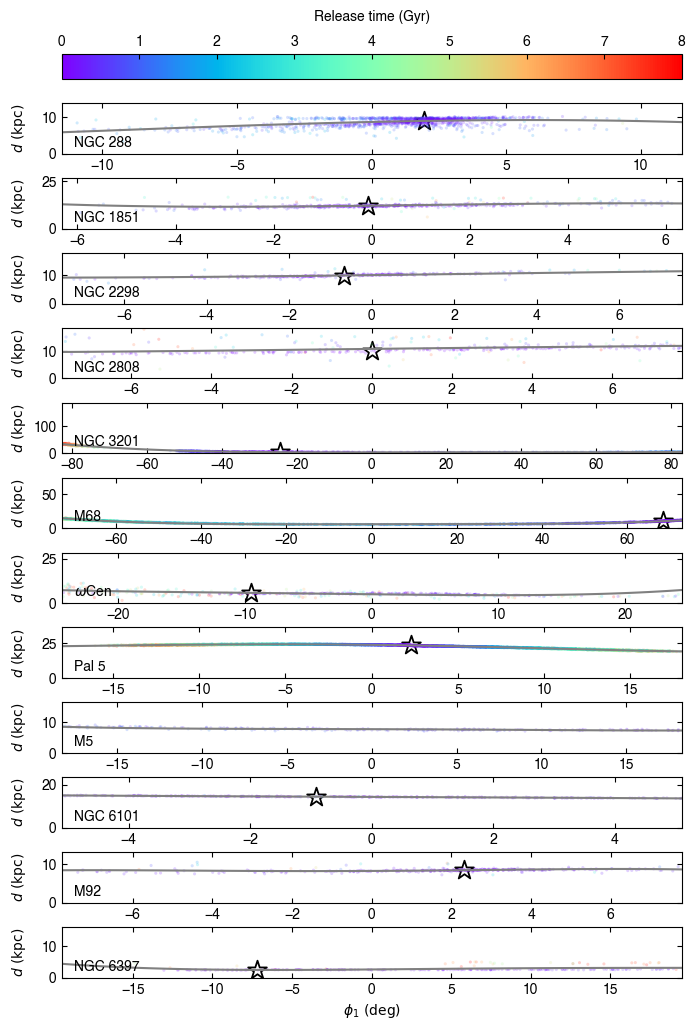

In [37]:
pd_dict = {}

fig = plt.figure(figsize=(8, 12))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

cmap = colormaps['rainbow']

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    y = mockstream.phi2hat
    y = mockstream.d
    # ax0.scatter(x, y, s=5, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    
    # plot observed stars and prog GC
    x_prog = stream.prog_phi1
    y_prog = stream.c_prog.distance.to_value('kpc')
    ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.3)
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    
    # plot fitted curve
    mask = np.ones_like(mockstream.phi1, dtype=bool)
    mask &= (np.abs(mockstream.phi2hat) < 3*widths_dict[key])
    # mask &= (-mockstream.release_time*0.978 < t90_dict[key]) & (-mockstream.release_time*0.978 > t10_dict[key])
    if key == 'NGC_6397':
        mask &= mockstream.d < 5
    ax0.scatter(x[mask], y[mask], s=5, ec='none', fc=cmap(-mockstream.release_time[mask]/t_tot.to_value('0.978*Gyr')), alpha=0.2, rasterized=True)
    pd = np.polyfit(mockstream.phi1[mask], y[mask], deg=4)
    pd_dict[key] = pd
    x = np.linspace(-1.5*width,1.5*width,100)
    y = np.poly1d(pd)(x)
    ax0.plot(x, y, c='gray')
    
    ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    
    ax0.set_xlim(-width,width)
    center = (np.min(y) + np.max(y)) / 2
    height = center - np.min(y)
    ax0.set_ylim(center-2*height, center+2*height)
    ax0.set_ylim(0, 1.5*np.max(y))
    ax0.set_ylabel(r'$d\ ({\rm kpc})$')

    ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

plt.show()

In [38]:
from matplotlib.colors import LinearSegmentedColormap
def power_law_colormap(cmap_name, gamma):
    # Get the existing colormap
    original_cmap = colormaps[cmap_name]
    
    # Create an array for the range [0, 1]
    t = np.linspace(0, 1, 1024)
    
    # Apply the power law transformation
    t_power = t ** gamma
    
    # Create the new colormap by interpolating the original colormap's colors
    new_cmap = LinearSegmentedColormap.from_list(f'{cmap_name}_power_{gamma}', original_cmap(t_power))
    
    return new_cmap

In [39]:

mass_func1 = lambda mmin, mmax: power_law_baumgardt_imf(mmin, mmax, gc.loc[key]['MF'], gc.loc[key]['MF'])
mass_func2 = lambda mmin, mmax: power_law_imf(mmin, mmax, gc.loc[key]['MF'])

print(mass_func1(0.08,0.8)/mass_func1(0.7,0.8))
print(mass_func2(0.08,0.8)/mass_func2(0.7,0.8))

4.872372296295751
4.872372296295751



NGC_288 NGC 288
t90 of segment = 1.40 Gyr
t90 of segment = 0.75 Gyr
t90 from Gaia = 1.40 Gyr
mass of a segment = 184.756 Msun
mass loss rate of segment = 1.80 Msun/Myr, age cut = 8 Gyr
mass of a segment = 406.344 Msun
mass loss rate of segment = 2.52 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 591.1 Msun
mass loss rate from Gaia = 2.24 Msun/Myr, age cut = 8 Gyr

NGC_1851 NGC 1851
t90 of segment = 0.26 Gyr
t90 of segment = 2.96 Gyr
t90 from Gaia = 2.96 Gyr
mass of a segment = 309.314 Msun
mass loss rate of segment = 12.83 Msun/Myr, age cut = 8 Gyr
mass of a segment = 275.031 Msun
mass loss rate of segment = 31.86 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 584.345 Msun
mass loss rate from Gaia = 17.85 Msun/Myr, age cut = 8 Gyr

NGC_2298 NGC 2298
t90 of segment = 0.25 Gyr
t90 of segment = 2.80 Gyr
t90 from Gaia = 2.80 Gyr
mass of a segment = 312.132 Msun
mass loss rate of segment = 5.92 Msun/Myr, age cut = 8 Gyr
mass of a segment = 307.39 Msun
mass loss rate of segment = 7.03 

/var/folders/3r/vrbpsfwj6p52jd6wsjcvn5vh0000gr/T/ipykernel_1906/1957678399.py:150: RuntimeWarning: invalid value encountered in scalar divide
  t90_right = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)


t90 of segment = 0.84 Gyr
t90 from Gaia = 0.84 Gyr
mass of a segment = 204.912 Msun
mass loss rate of segment = 5.29 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 204.912 Msun
mass loss rate from Gaia = 5.29 Msun/Myr, age cut = 8 Gyr

NGC_6101 NGC 6101
t90 of segment = 0.32 Gyr
t90 from Gaia = 0.32 Gyr
mass of a segment = 562.334 Msun
mass loss rate of segment = 6.44 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 562.334 Msun
mass loss rate from Gaia = 6.44 Msun/Myr, age cut = 8 Gyr

NGC_6341 M92
t90 of segment = 0.35 Gyr
t90 of segment = 0.26 Gyr
t90 from Gaia = 0.35 Gyr
mass of a segment = 238.703 Msun
mass loss rate of segment = 8.97 Msun/Myr, age cut = 8 Gyr
mass of a segment = 200.024 Msun
mass loss rate of segment = 3.07 Msun/Myr, age cut = 8 Gyr
total mass from Gaia = 438.727 Msun
mass loss rate from Gaia = 4.78 Msun/Myr, age cut = 8 Gyr

NGC_6397 NGC 6397
t90 of segment = 0.02 Gyr
t90 of segment = 2.42 Gyr
t90 from Gaia = 2.42 Gyr
mass of a segment = 19.7781 Msun
mass loss

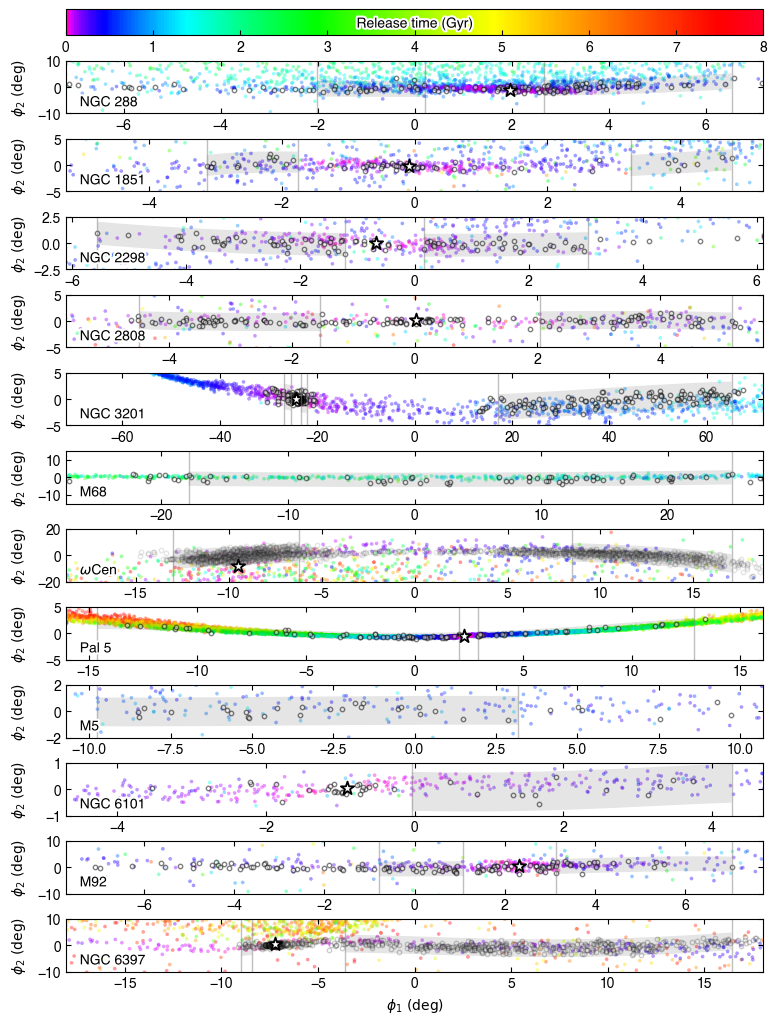

In [40]:
def round_range(x):
    if x <= 2.5:
        return 0.5 * ((x//0.5) + 1)
    if x <= 5:
        return 2.5 * ((x//2.5) + 1)
    if x <= 25:
        return 5 * ((x//5) + 1)
    return 10 * ((x//10) + 1)

mdot_dict = {}
# mdot_broken_dict = {}
mdot_alphas_dict = {}
ndot_alphas_dict = {}
mean_weight_alphas_dict = {}
t10_dict = {}
t90_dict = {}
n_obs_dict = {}
mstar_mean_dict = {}
age_cuts = [8]

# mass_func = kroupa
imdividual_alpha = True
# broken_powerlaw = True
broken_powerlaw = False
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
alphas = np.arange(-.5,2.01,0.1)
mass_funcs = [lambda mmin, mmax, alpha=alpha: power_law_imf(mmin, mmax, -alpha) for alpha in alphas]
yaxis = 'phi2'
distance_mode = 'mock' # mock or prog
mfmin = 0.08

sep_width = False

# fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,30), sharex=False, sharey=False)

fig = plt.figure(figsize=(9, 12.5))
gs = gridspec.GridSpec(len(gc_stream_ids)+1, 1, height_ratios=[0.5] + [1] * len(gc_stream_ids))
plt.subplots_adjust(hspace=0.5)
axs = [fig.add_subplot(gs[i+1]) for i in range(len(gc_stream_ids))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

# cmap = colormaps['gist_rainbow_r']
cmap = power_law_colormap('gist_rainbow_r', 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

txt = cbar.ax.text(0.5, 0.45, r'Release time (Gyr)', transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# for key, ax0 in zip(['Pal_5'], [axs[0]]):
for key, ax0 in zip(gc_stream_list, axs):
    print('')
    print(key, display_name_convert(key))
    
    stream = ds_i24[key]
    mockstream = mockstreams[key]
    
    # plot mock stars and prog GC
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    if yaxis == 'phi2hat':
        y = mockstream.phi2hat
    elif yaxis == 'phi2':
        y = mockstream.phi2
    else:
        raise AttributeError
    ax0.scatter(x, y, s=7, ec='none', fc=cmap(-mockstream.release_time/t_tot.to_value('0.978*Gyr')), alpha=0.4, rasterized=True)
    
    # plot observed stars and prog GC
    x = stream.phi1
    x_prog = stream.prog_phi1
    if yaxis == 'phi2hat':
        y = stream.phi2hat
        y_prog = stream.prog_phi2hat
    elif yaxis == 'phi2':
        y = stream.phi2
        y_prog = stream.prog_phi2
    else:
        raise AttributeError
    alpha = 0.5
    if key == 'NGC_5139':
        alpha = 0.1
    if key == 'NGC_6397':
        alpha = 0.2
    ax0.scatter(x, y, s=10, marker='o', ec='k', fc='w', lw=1, alpha=alpha, rasterized=True)
    ax0.scatter(x_prog, y_prog, s=100, ec='k', fc='w', marker='*', lw=1.3)
    
    # detect segments
    segs = detect_segs(stream)
    segs = segs_dict[key]
    segs_left = detect_segs(stream, percentiles=[5,15])
    segs_right = detect_segs(stream, percentiles=[85,95])
    
    # distance and distance modulus
    dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
    dist_mod = 5*(np.log10(dist)+2)
    
    # select isochrone
    iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_gaia_list, 'G_BPmag', 'G_RPmag', 'Gmag')
    
    # calculate mass of stars, minimum observable mass, maximum survived mass
    masses = calc_mass(stream.mag - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    mass_min = calc_mass(G_limit - dist_mod, iso_gaia_list[iso_idx], 'Gmag')
    mass_max = np.max(iso_gaia_list[iso_idx]['Mini'][iso_gaia_list[iso_idx]['label']<=3])
    mass_max = np.full_like(mass_min, fill_value=mass_max)
    
    # weights of stars to correct for missing stars
    if imdividual_alpha:
        mass_func = lambda mmin, mmax: power_law_imf(mmin, mmax, gc.loc[key]['MF'])
    if broken_powerlaw:
        mass_func = lambda mmin, mmax: power_law_baumgardt_imf(mmin, mmax, alow[key], ahigh[key])
    weights = mass_func(mfmin, mass_max) / mass_func(mass_min, mass_max)

    # for alpha test
    weights_alphas = []
    for mf in mass_funcs:
        weights_alphas.append(mf(mfmin, mass_max) / mass_func(mass_min, mass_max))
    
    # print('total mass = %g Msun'%np.sum(masses*weights))
    
    mtot = 0
    mtot_alphas = np.zeros_like(alphas, dtype=float)
    t10 = np.inf
    t90 = 0
    n_obs = 0
    select_weight_sum = np.zeros_like(age_cuts, dtype=float)
    # now, look at individual segments
    gaus_widths = calc_selection_function(stream, segs)
    mock_gaus_widths = calc_selection_function(mockstream, segs)

    for seg, width, mockwidth, seg_left, seg_right in zip(segs, gaus_widths, mock_gaus_widths, segs_left, segs_right):
        # decide the time range
        mask = (mockstream.phi1>=seg_left[0]) & (mockstream.phi1<=seg_left[1])
        select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
        t90_left = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
        mask = (mockstream.phi1>=seg_right[0]) & (mockstream.phi1<=seg_right[1])
        select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
        t90_right = np.sum(-select_weights*mockstream.release_time[mask]*0.978) / np.sum(select_weights)
        print('t90 of segment = %.2f Gyr'%np.nanmax([t90_left, t90_right]))
        t90 = np.nanmax([t90_left, t90_right]) if np.nanmax([t90_left, t90_right]) > t90 else t90
        t10 = np.nanmin([t90_left, t90_right]) if np.nanmin([t90_left, t90_right]) < t10 else t10
    
    print('t90 from Gaia = %.2f Gyr'%t90)
    t90_dict[key] = t90
    t10_dict[key] = t10

    weights_alphas_all = None
    
    for seg, width, mockwidth in zip(segs, gaus_widths, mock_gaus_widths):
        if not sep_width:
            width = widths_dict[key]
            mockwidth = mockwidths_dict[key]
        # plot the Gaussian width
        for factor in [3]:
            if yaxis == 'phi2hat':
                x = seg
                y = np.zeros_like(seg)
            elif yaxis == 'phi2':
                x = np.linspace(seg[0], seg[1], 11)
                y = stream.fit_poly(x)
            ax0.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)
            # ax0.plot(x, y+factor*width, c='w', alpha=1)
            # ax0.plot(x, y-factor*width, c='w', alpha=1)
        # ax0.fill_between(seg, -50,50, fc='k', ec='none', alpha=0.1)
        ax0.plot([seg[0],seg[0]], [-50, 50], c='gray', alpha=0.5, lw=1)
        ax0.plot([seg[1],seg[1]], [-50, 50], c='gray', alpha=0.5, lw=1)

        if distance_mode == 'prog':
            weights_seg = weights
            # for alpha test
            weights_alphas_seg =  weights_alphas
        elif distance_mode == 'mock':
            pd = pd_dict[key]     
            dist_seg = np.poly1d(pd)(stream.phi1)
            dist_mod_seg = 5*(np.log10(dist_seg)+2)
            mass_min_seg = calc_mass(G_limit - dist_mod_seg, iso_gaia_list[iso_idx], 'Gmag')
            weights_seg = mass_func(mfmin, mass_max) / mass_func(mass_min_seg, mass_max)
            mstar_mean_dict[key] = mass_func(mfmin, mass_max[0]) / power_law_imf(mfmin, mass_max[0], gc.loc[key]['MF']-1)
            if broken_powerlaw:
                mstar_mean_dict[key] = mass_func(mfmin, mass_max[0]) / power_law_baumgardt_imf(mfmin, mass_max[0], alow[key]-1, ahigh[key]-1)
            # for alpha test
            weights_alphas_seg =  []
            mstar_mean_alphas = []
            for mf, mfslope in zip(mass_funcs, alphas):
                weights_alphas_seg.append(mf(mfmin, mass_max) / mf(mass_min_seg, mass_max))
                mstar_mean_alphas.append(mf(mfmin, mass_max[0]) / power_law_imf(mfmin, mass_max[0], -mfslope-1))

        if weights_alphas_all is None:
            weights_alphas_all = np.array(weights_alphas_seg)
        else:
            weights_alphas_all = np.hstack([weights_alphas_all, weights_alphas_seg])
        
        mask = (stream.phi1>=seg[0]) & (stream.phi1<=seg[1])
        mseg = np.sum(masses[mask]*weights_seg[mask])
        print('mass of a segment = %g Msun'%mseg)
        mtot += mseg
        # for alpha test
        mseg_alphas = []
        for i, weights_alpha_seg in enumerate(weights_alphas_seg):
            mseg_alphas.append(np.sum(masses[mask]*weights_alpha_seg[mask]))
            mtot_alphas[i] += mseg_alphas[-1]
            
        n_obs += len(stream.phi1[mask])
    
        for i, age_cut in enumerate(age_cuts):
            mask = (mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1]) & (-mockstream.release_time*0.978<age_cut)
            select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
            mdot = ndot * mseg / np.sum(select_weights)
            select_weight_sum[i] += np.sum(select_weights)
    
            print('mass loss rate of segment = %.2f Msun/Myr, age cut = %g Gyr'%(mdot,age_cut))
    
    print('total mass from Gaia = %g Msun'%mtot)
    for i, age_cut in enumerate(age_cuts):
        print('mass loss rate from Gaia = %.2f Msun/Myr, age cut = %g Gyr'%(ndot*mtot/select_weight_sum[i],age_cut))
        mdot_dict[key] = ndot*mtot/select_weight_sum
        
    for i, mtot_alpha in enumerate(mtot_alphas):
        # print('mass loss rate from Gaia = %.2f Msun/Myr, alpha = %g'%(ndot*mtot_alpha/select_weight_sum[0],alphas[i]))
        mdot_alphas_dict[key] = ndot*mtot_alphas/select_weight_sum[0]
        ndot_alphas_dict[key] = ndot*mtot_alphas/select_weight_sum[0] / np.array(mstar_mean_alphas)
        mean_weight_alphas_dict[key] = np.mean(weights_alphas_all, axis=1)
        
    n_obs_dict[key] = n_obs

    txt = ax0.text(0.02, 0.08, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])
    
    width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
    width = np.max(np.abs(segs))
    height = np.percentile(stream.phi2, 90) - np.percentile(stream.phi2, 10)
    ax0.set_xlim(-1.1*width,1.1*width)
    ylim = round_range(2*height)
    ax0.set_ylim(-ylim,ylim)
    ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

    ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
fig.align_ylabels(axs)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/stream_fit.pdf', dpi=300, bbox_inches ='tight')
plt.show()

In [41]:
# note: this need to be done manually!

mdot_broken_dict = mdot_dict

In [165]:
# save mock streams

# for key in gc_stream_list:
#     out = np.column_stack((mockstreams[key].ra, mockstreams[key].dec, mockstreams[key].release_time*0.978))
#     np.savetxt('/Users/ybchen/Downloads/stream_coord/%s.txt'%key, out, fmt='%.4f %.4f %.4f', header='RA(deg) Dec(deg) ReleaseTime')


# for key in gc_stream_list:
#     out = np.column_stack((mockstreams[key].ra, mockstreams[key].dec, mockstreams[key].d, 
#                            mockstreams[key].mu_ra, mockstreams[key].mu_dec, mockstreams[key].vr, 
#                            mockstreams[key].release_time*0.978))
#     np.savetxt('/Users/ybchen/Downloads/stream_coord/%s_6d.txt'%key, out, fmt='%.4f %.4f %.4f %.4f %.4f %.4f %.4f', 
#         header='RA(deg) Dec(deg) d(kpc) mu_RA_cosDec(mas/yr) mu_Dec(mas/yr) vr(km/s) ReleaseTime (Gyr)')

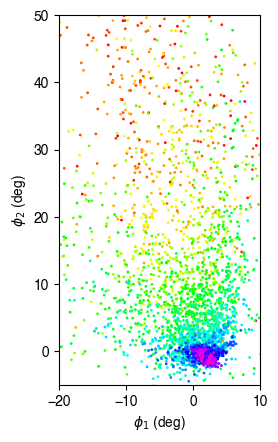

In [209]:
ra, dec, d, mu_ra, mu_dec, vr, t = np.loadtxt('/Users/ybchen/Downloads/stream_coord/NGC_288_6d.txt', unpack=True)

c = coord.SkyCoord(ra*u.deg, dec*u.deg, distance=d*u.kpc,
            pm_ra_cosdec=mu_ra*u.mas/u.yr, pm_dec=mu_dec*u.mas/u.yr,
            radial_velocity=vr*u.km/u.s)

mat = np.array([
    [ 0.85786144,  0.18693242, -0.47867527],
    [ 0.48014833,  0.04034979,  0.8762588 ],
    [ 0.18311562, -0.98154377, -0.05514076]])

import gala.coordinates as galac
frame = galac.GreatCircleICRSFrame.from_R(mat)

c_g = c.transform_to(frame)

cmap = power_law_colormap('gist_rainbow_r', 0.5)
plt.scatter(c_g.phi1, c_g.phi2, s=1, c=-t, cmap=cmap, vmin=0, vmax=5)

plt.xlabel('$\phi_1$ (deg)')
plt.ylabel('$\phi_2$ (deg)')
plt.xlim(-20, 10)
plt.ylim(-5, 50)
plt.gca().set_aspect('equal')
plt.show()

In [43]:
for key in gc_stream_list:
    print('')
    print(key, display_name_convert(key))
    rapo = gc.loc[key]['RAPO']
    rperi = gc.loc[key]['RPERI']
    e = (rapo-rperi) / (rapo+rperi)
    print('e =', e, 'rperi =', rperi)


NGC_288 NGC 288
e = 0.7295024526979678 rperi = 1.93

NGC_1851 NGC 1851
e = 0.9134615384615385 rperi = 0.9

NGC_2298 NGC 2298
e = 0.888888888888889 rperi = 0.97

NGC_2808 NGC 2808
e = 0.8622448979591837 rperi = 1.08

NGC_3201 NGC 3201
e = 0.5073833431777909 rperi = 8.34

NGC_4590 M68
e = 0.535686274509804 rperi = 8.88

NGC_5139 $\omega$Cen
e = 0.65083135391924 rperi = 1.47

Pal_5 Pal 5
e = 0.32778198334594993 rperi = 8.88

NGC_5904 M5
e = 0.756463094792057 rperi = 3.25

NGC_6101 NGC 6101
e = 0.5562812976268235 rperi = 10.19

NGC_6341 M92
e = 0.7893850042123 rperi = 1.25

NGC_6397 NGC 6397
e = 0.41573033707865165 rperi = 2.6



Pal_5 Pal 5
127
80


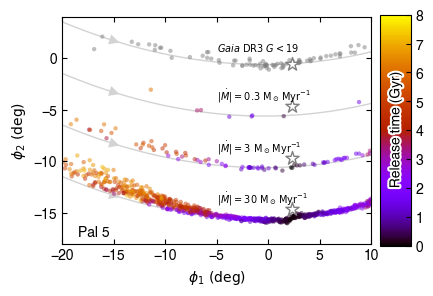

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

import gala.potential as gp
import gala.dynamics as gd
from gala.dynamics import mockstream as ms
from gala.units import galactic

age_cuts = [8]

key = 'Pal_5'

# mass_func = kroupa
imdividual_alpha = True
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
alphas = np.arange(-.5,2.01,0.1)
mass_funcs = [lambda mmin, mmax, alpha=alpha: power_law_imf(mmin, mmax, -alpha) for alpha in alphas]
yaxis = 'phi2'
distance_mode = 'mock' # mock or prog
mfmin = 0.08

sep_width = False

norb = 30
tlim = norb * T_dict[key] # Gyr

# fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,30), sharex=False, sharey=False)

fig = plt.figure(figsize=(4.5, 3))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.1])
plt.subplots_adjust(wspace=0.05)
ax0 = fig.add_subplot(gs[0])

# make color bar
cbar_ax = fig.add_subplot(gs[1])
cbar_ax.tick_params(direction='in')


# cmap = colormaps['rainbow']
cmap = power_law_colormap('gnuplot', 1)
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=tlim/T_dict[key]))
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label(r'Release time (orbit $=%.3f$ Gyr)'%T_dict[key], labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# txt = cbar.ax.text(0.5, 0.5, r'Release time (orbit = %.3f Gyr)'%T_dict[key], rotation=90, transform=cbar.ax.transAxes, va='center', ha='center')
txt = cbar.ax.text(0.5, 0.5, r'Release time (Gyr)', rotation=90, transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

print('')
print(key, display_name_convert(key))

stream = ds_i24[key]
mockstream = mockstreams[key]

seg0 = segs_dict[key][0]
seg1 = segs_dict[key][1]

# plot mock stars and prog GC
x = mockstream.phi1
x_prog = mockstream.prog_phi1
if yaxis == 'phi2hat':
    y = mockstream.phi2hat
elif yaxis == 'phi2':
    y = mockstream.phi2
else:
    raise AttributeError

maskseg = ((x > seg0[0]) & (x < seg0[1])) | ((x > seg1[0]) & (x < seg1[1]))
num = int(len(x) * (80 / len(x[maskseg])))
print(num)

rng = np.random.default_rng(10)
idxs = rng.choice(len(x), int(num/10), replace=False)
ax0.scatter(x[idxs], y[idxs]-5, s=10, ec='none', fc=cmap(-mockstream.release_time[idxs]/tlim), alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog-5, s=100, ec='gray', fc='w', marker='*', lw=1)
ax0.text(-5,-4.5, r'$|\dot{M}| = 0.3\ {\rm M_\odot\,Myr^{-1}}$', va='bottom', ha='left', fontsize=7)

idxs = rng.choice(len(x), num, replace=False)
ax0.scatter(x[idxs], y[idxs]-10, s=10, ec='none', fc=cmap(-mockstream.release_time[idxs]/tlim), alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog-10, s=100, ec='gray', fc='w', marker='*', lw=1)
ax0.text(-5,-9.5, r'$|\dot{M}| = 3\ {\rm M_\odot\,Myr^{-1}}$', va='bottom', ha='left', fontsize=7)

idxs = rng.choice(len(x), num*10, replace=False)
ax0.scatter(x[idxs], y[idxs]-15, s=10, ec='none', fc=cmap(-mockstream.release_time[idxs]/tlim), alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog-15, s=100, ec='gray', fc='w', marker='*', lw=1)
ax0.text(-5,-14.5, r'$|\dot{M}| = 30\ {\rm M_\odot\,Myr^{-1}}$', va='bottom', ha='left', fontsize=7)

# plot observed stars and prog GC
x = stream.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
ax0.scatter(x, y, s=10, ec='none', fc='gray', lw=1, alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog, s=100, ec='gray', fc='w', marker='*', lw=1)
ax0.text(-5,0.5, r'$Gaia\ {\rm DR3}\ G<19$', va='bottom', ha='left', fontsize=7)

maskseg = ((x > seg0[0]) & (x < seg0[1])) | ((x > seg1[0]) & (x < seg1[1]))
print(len(y[maskseg]))


# plot traj

c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
gc_w0 = gd.PhaseSpacePosition(c_gc)
gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]

for integrate_time, idx in zip([0.0978, -0.0978], [300, 300]):
    time_sat, orbit_sat = ags.integrate_prog(integrate_time, 1000, pot_agama, gc_posvel)
    orbit = coord.Galactocentric(x=orbit_sat[:,0]*u.kpc, y=orbit_sat[:,1]*u.kpc, z=orbit_sat[:,2]*u.kpc, 
        v_x=orbit_sat[:,3]*u.km/u.s, v_y=orbit_sat[:,4]*u.km/u.s, v_z=orbit_sat[:,5]*u.km/u.s).transform_to(coord.ICRS()).transform_to(stream.GreatCircle())
    x = orbit.phi1.wrap_at(180*u.deg).to_value(u.deg)
    y = orbit.phi2.to_value(u.deg)
    ax0.plot(x, y, lw=1, c='lightgray', zorder=0)
    ax0.arrow(x[idx], y[idx], x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=1, head_length=1, fc='lightgray', ec='none', zorder=0)
    ax0.plot(x, y-5, lw=1, c='lightgray', zorder=0)
    ax0.arrow(x[idx], y[idx]-5, x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=1, head_length=1, fc='lightgray', ec='none', zorder=0)
    ax0.plot(x, y-10, lw=1, c='lightgray', zorder=0)
    ax0.arrow(x[idx], y[idx]-10, x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=1, head_length=1, fc='lightgray', ec='none', zorder=0)
    ax0.plot(x, y-15, lw=1, c='lightgray', zorder=0)
    ax0.arrow(x[idx], y[idx]-15, x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=1, head_length=1, fc='lightgray', ec='none', zorder=0)

# detect segments
segs = segs_dict[key]
segs_left = detect_segs(stream, percentiles=[5,15])
segs_right = detect_segs(stream, percentiles=[85,95])

# for seg in segs:
#     assert not sep_width
#     width = widths_dict[key]
#     mockwidth = mockwidths_dict[key]
#     # plot the Gaussian width
#     for factor in [1,2,3]:
#         if yaxis == 'phi2hat':
#             x = seg
#             y = np.zeros_like(seg)
#         elif yaxis == 'phi2':
#             x = np.linspace(seg[0], seg[1], 11)
#             y = stream.fit_poly(x)
#         ax0.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)
        
#     ax0.plot([seg[0],seg[0]], [-50, 50], c='gray', alpha=0.5, lw=1)
#     ax0.plot([seg[1],seg[1]], [-50, 50], c='gray', alpha=0.5, lw=1)

ax0.text(0.05, 0.02, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')

width = np.percentile(stream.phi1, 90) - np.percentile(stream.phi1, 10)
width = np.max(np.abs(segs))
height = np.percentile(stream.phi2, 90) - np.percentile(stream.phi2, 10)
ax0.set_xlim(-20,10)
ax0.set_ylim(-18,4)
ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)
    
ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
ax0.set_aspect('equal')

# plt.savefig('/Users/ybchen/Downloads/Pal_5.pdf', dpi=300, bbox_inches ='tight')
plt.show()

**just NGC 288, the special case**


NGC_288 NGC 288


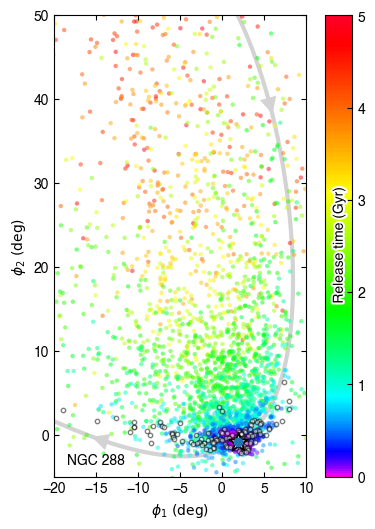

In [241]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

import gala.potential as gp
import gala.dynamics as gd
from gala.dynamics import mockstream as ms
from gala.units import galactic

age_cuts = [8]

key = 'NGC_288'

greatcircle = True
wrap_ra = True
aitoff = True

aitoff = False if greatcircle else aitoff
wrap_ra = True if aitoff else wrap_ra

# mass_func = kroupa
imdividual_alpha = True
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
alphas = np.arange(-.5,2.01,0.1)
mass_funcs = [lambda mmin, mmax, alpha=alpha: power_law_imf(mmin, mmax, -alpha) for alpha in alphas]
yaxis = 'phi2'
distance_mode = 'mock' # mock or prog
mfmin = 0.08

sep_width = False

norb = 30

# fig, axs = plt.subplots(len(gc_stream_ids), 1, figsize=(8,30), sharex=False, sharey=False)

if greatcircle:
    fig = plt.figure(figsize=(4, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.1])
else:
    fig = plt.figure(figsize=(10, 4))
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 0.05])
plt.subplots_adjust(wspace=0.05)
if aitoff:
    ax0 = fig.add_subplot(gs[0], projection='aitoff')
else:
    ax0 = fig.add_subplot(gs[0])

# make color bar
cbar_ax = fig.add_subplot(gs[1])
cbar_ax.tick_params(direction='in')


# cmap = colormaps['rainbow']
cmap = power_law_colormap('gist_rainbow_r', 0.5)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=tlim))
# sm.set_array([])  # Dummy array for the colorbar

# # temp
# cmap = colormaps['rainbow']
# vmin = 4
# vmax = 11
# sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))


cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
# cbar.set_label(r'Release time (orbit $=%.3f$ Gyr)'%T_dict[key], labelpad=10)
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')

# # temp
# txt = cbar.ax.text(0.5, 0.5, r'Heliocentric distance (kpc)', rotation=90, transform=cbar.ax.transAxes, va='center', ha='center')

# txt = cbar.ax.text(0.5, 0.5, r'Release time (orbit = %.3f Gyr)'%T_dict[key], rotation=90, transform=cbar.ax.transAxes, va='center', ha='center')
txt = cbar.ax.text(0.5, 0.5, r'Release time (Gyr)', rotation=90, transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

print('')
print(key, display_name_convert(key))

stream = ds_i24[key]
mockstream = mockstreams[key]

# plot mock stars and prog GC
if greatcircle:
    x = mockstream.phi1
    x_prog = mockstream.prog_phi1
    if yaxis == 'phi2hat':
        y = mockstream.phi2hat
    elif yaxis == 'phi2':
        y = mockstream.phi2
    else:
        raise AttributeError
else:
    x = np.copy(mockstream.ra)
    if wrap_ra:
        x[x>180] -= 360
    y = np.copy(mockstream.dec)
    if aitoff:
        x *= np.pi/180
        y *= np.pi/180

mask = -mockstream.release_time/T_dict[key] <= norb
ax0.scatter(x[mask], y[mask], s=2 if aitoff else 10, ec='none', fc=cmap(-mockstream.release_time[mask]/tlim), alpha=0.5, rasterized=True)

# # temp
# cnorm = (mockstream.d - vmin) / (vmax - vmin)
# ax0.scatter(x[mask], y[mask], s=10, ec='none', fc=cmap(cnorm[mask]), alpha=1, rasterized=True)

# plot observed stars and prog GC
if greatcircle:
    x = stream.phi1
    x_prog = stream.prog_phi1
    if yaxis == 'phi2hat':
        y = stream.phi2hat
        y_prog = stream.prog_phi2hat
    elif yaxis == 'phi2':
        y = stream.phi2
        y_prog = stream.prog_phi2
    else:
        raise AttributeError
else:
    x = np.copy(stream.ra)
    x_prog = np.copy(stream.c_prog.ra.to_value('deg'))
    if wrap_ra:
        x[x>180] -= 360
        x_prog = x_prog - 360 if x_prog > 180 else x_prog
    y = np.copy(stream.dec)
    y_prog = np.copy(stream.c_prog.dec.to_value('deg'))
    if aitoff:
        x *= np.pi/180
        x_prog *= np.pi/180
        y *= np.pi/180
        y_prog *= np.pi/180
ax0.scatter(x, y, s=10, ec='k', fc='w', lw=1, alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog, s=200, ec='k', fc='w', marker='*', lw=1.3)

# plot traj

c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
gc_w0 = gd.PhaseSpacePosition(c_gc)
gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]

idx = 300 if greatcircle else 250
integrate_dur = 0.0978 if greatcircle else 2*0.0978
for integrate_time, idx in zip([integrate_dur, -integrate_dur], [idx, idx]):
    time_sat, orbit_sat = ags.integrate_prog(integrate_time, 1000, pot_agama, gc_posvel)
    orbit = coord.Galactocentric(x=orbit_sat[:,0]*u.kpc, y=orbit_sat[:,1]*u.kpc, z=orbit_sat[:,2]*u.kpc, 
        v_x=orbit_sat[:,3]*u.km/u.s, v_y=orbit_sat[:,4]*u.km/u.s, v_z=orbit_sat[:,5]*u.km/u.s).transform_to(coord.ICRS())
    if greatcircle:
        orbit = orbit.transform_to(stream.GreatCircle())
        x = orbit.phi1.wrap_at(180*u.deg).to_value(u.deg)
        y = orbit.phi2.to_value(u.deg)
    else:
        x = orbit.ra.to_value(u.deg)
        if wrap_ra:
            x[x>180] -= 360
        y = orbit.dec.to_value(u.deg)
        if aitoff:
            x *= np.pi/180
            y *= np.pi/180
    ax0.plot(x, y, lw=1.5 if aitoff else 3, c='lightgray', zorder=0)
    arrowsize = 2 if greatcircle else (0.1 if aitoff else 4)
    ax0.arrow(x[idx], y[idx], x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=arrowsize, head_length=arrowsize, fc='lightgray', ec='none', zorder=0)

ax0.scatter(x_prog, y_prog)

if greatcircle:
    ax0.set_xlim(-20,10)
    ax0.set_ylim(-5,50)
    ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
    ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')
    ax0.text(0.05, 0.02, r'%s'%display_name_convert(key), transform=ax0.transAxes, va='bottom', ha='left')
else:
    # ax0.set_xlim(0,360)
    # if wrap_ra:
    #     ax0.set_xlim(-150,30)
    # ax0.set_ylim(-90,00)
    ax0.set_xlabel(r'RA (deg)')
    ax0.set_ylabel(r'Dec (deg)')

if aitoff:
    ax0.grid(True)
else:
    ax0.set_aspect('equal')
    ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/NGC_288.pdf', dpi=300, bbox_inches ='tight')
plt.show()

In [238]:
gc.loc['NGC_288']['RPERI']

1.93

In [239]:
idx = (gc['R_GC'] / gc['RAPO'] > 0.95) & (gc['RPERI'] / gc['RAPO'] < 0.2) & (gc['R_GC'] > 5) 

gc[idx]

,logm,feh,RA,DEC,l,b,Rsun,ERsun,R_GC,<RV>,...,T_Diss,M_Low,M_High,MF,symbol,DMF,sig0,vesc,etac,etah
name,,,,,,,,,,,,,,,,,,,,,
NGC_288,4.992995,-1.32,13.188500,-26.582611,151.285,-89.380,8.99,0.09,12.21,-44.45,...,9.3,0.22,0.82,-0.66,+-,0.11,3.1,10.9,-0.31,-0.10
NGC_1904,5.193125,-1.60,81.045837,-24.524416,227.230,-29.350,13.08,0.18,19.09,205.76,...,2.0,0.52,0.80,-1.38,+-,0.23,6.7,27.6,-0.42,-0.11
NGC_5634,5.342423,-1.88,217.405335,-5.976430,342.210,49.260,25.96,0.62,21.84,-16.07,...,34.5,99.90,99.90,-0.93,+-,0.30,5.9,24.2,-0.39,-0.08
NGC_5946,5.136721,-1.29,233.869051,-50.659713,327.583,4.191,9.64,0.51,5.20,137.60,...,2.1,0.52,0.80,-0.65,+-,0.16,6.2,24.3,-0.38,-0.11
NGC_6121,4.968016,-1.16,245.896744,-26.525749,350.973,15.972,1.85,0.02,6.45,71.22,...,2.3,0.44,0.80,-0.33,+-,0.15,4.7,18.8,-0.39,-0.11
NGC_6205,5.671173,-1.53,250.421814,36.459862,59.007,40.913,7.42,0.08,8.64,-244.90,...,26.4,0.30,0.74,-0.94,+-,0.12,8.9,32.4,-0.26,-0.10
NGC_6229,5.459392,-1.47,251.745249,47.527796,73.639,40.306,30.11,0.47,29.45,-137.89,...,16.2,0.65,0.79,-1.47,+-,0.48,6.7,25.3,-0.34,-0.11
NGC_6284,5.378398,-1.26,256.120114,-24.764799,358.347,9.939,14.21,0.42,6.32,28.62,...,7.3,0.43,0.82,-0.05,+-,0.16,6.8,27.6,-0.38,-0.10
IC_1257,4.838219,-1.70,261.785431,-7.093056,16.528,15.145,26.59,1.43,19.27,-137.97,...,1.0,99.90,99.90,0.12,+-,0.30,1.7,6.7,-0.38,-0.13


**Compare with [Carl J. Grillmair (2024)](https://arxiv.org/abs/2409.17361)**

In [224]:
# agama

# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

release_type == 'uniform'

pot_agama_i13 = agama.Potential("../data/Irrgang13.ini")

for key in ['NGC_288']:
# for key in gc_stream_list:
    stream = ds_i24[key]
    
    gc_mass = 10**stream.prog['logm']
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama_i13, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    # T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
    
    assert np.sum(nhalf_release) == nhalf
        
    # time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
    #     ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
    #         pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_grillmair24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama_i13, gc_posvel, gc_mass, pot_sat=None, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())

    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)
    
    mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
    mockstream.construct_polynomial_coord(p=stream.p, deg=4)
    mockstream.set_release_time(time_stream)

7998 orbits complete (1400 orbits/s)


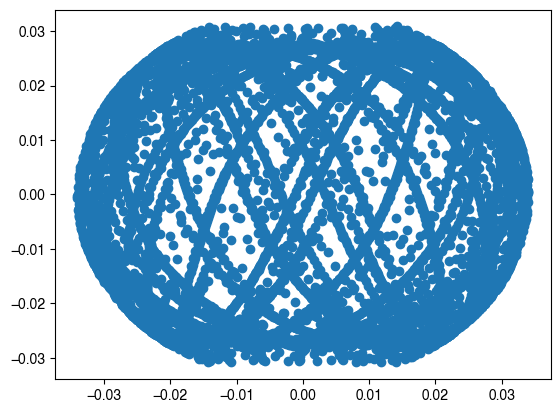

In [225]:
dxv = ic_stream - np.repeat(orbit_sat[:-1], 2, axis=0)
r = np.sqrt(dxv[:,0]**2+dxv[:,1]**2+dxv[:,2]**2)
plt.scatter(dxv[:,0], dxv[:,2])

In [226]:
# gala

key = 'NGC_288'
stream = ds_i24[key]

pot = gp.BovyMWPotential2014(units=galactic)
H = gp.Hamiltonian(pot)

c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
prog_w0 = gd.PhaseSpacePosition(c_gc)
prog_mass = 10**gc.loc[key]['logm'] * u.Msun


# Chen+24 (with prog.)
df = ms.LagrangeCloudStreamDF(1.0*u.km/u.s)
# df = ms.FardalStreamDF(gala_modified=False)
# df = ms.ChenStreamDF()
prog_pot = gp.PlummerPotential(m=prog_mass, b=4*u.pc, units=galactic)
gen = ms.MockStreamGenerator(df, H)
# gen = ms.MockStreamGenerator(df, H, progenitor_potential=prog_pot)
stream_c24b, prog_c24b = gen.run(prog_w0, prog_mass, dt=-2*u.Myr, n_steps=1500)

mockstream = stream_c24b.to_coord_frame(coord.ICRS())

mockstream = sd.StreamDataset('mock', None, 
    mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
    None, 
    mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
    None, None, 
    mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
    None, None, None, stream.prog)

mockstream.construct_greatcircle_coord(GreatCircle=stream.GreatCircle)
mockstream.construct_polynomial_coord(p=stream.p, deg=4)
mockstream.set_release_time(stream_c24b.release_time.to_value('0.978*Gyr'))


NGC_288 NGC 288


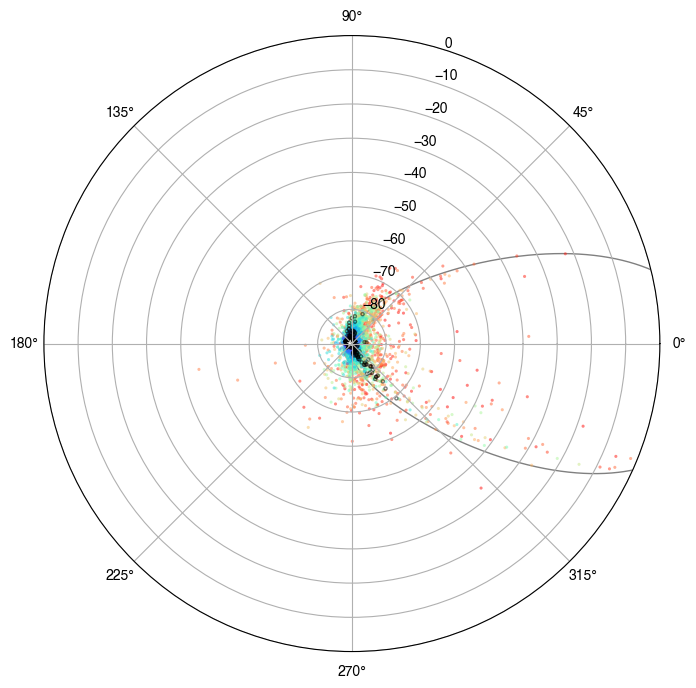

In [227]:
fig, ax0 = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

key = 'NGC_288'

print('')
print(key, display_name_convert(key))

stream = ds_i24[key]
# mockstream = mockstreams[key]

tlim = 3 / 0.978
cmap = colormaps['rainbow']
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=tlim))

# to galactic coord
stream_c_galcoord = stream.c.transform_to(coord.Galactic())
stream_prog_galcoord = stream.c_prog.transform_to(coord.Galactic())
mockstream_c_galcoord = mockstream.c.transform_to(coord.Galactic())

# plot mock stars and prog GC
x = mockstream_c_galcoord.l.to_value('rad')
y = mockstream_c_galcoord.b.to_value('deg')

mask = -mockstream.release_time <= tlim #/T_dict[key] <= norb
ax0.scatter(x[mask], y[mask], s=5, ec='none', fc=cmap(-mockstream.release_time[mask]/tlim), alpha=0.5, rasterized=True)

# plot observed stars and prog GC
x = stream_c_galcoord.l.to_value('rad')
y = stream_c_galcoord.b.to_value('deg')
x_prog = stream_prog_galcoord.l.to_value('rad')
y_prog = stream_prog_galcoord.b.to_value('deg')

ax0.scatter(x, y, s=5, ec='k', fc='none', lw=1, alpha=0.5, rasterized=True)
ax0.scatter(x_prog, y_prog, s=100, ec='k', fc='w', marker='*', lw=1.3)

# plot traj

c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
gc_w0 = gd.PhaseSpacePosition(c_gc)
gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]

for integrate_time, idx in zip([0.0978, -0.0978], [300, 300]):
    time_sat, orbit_sat = ags.integrate_prog(integrate_time, 1000, pot_agama, gc_posvel)
    orbit = coord.Galactocentric(x=orbit_sat[:,0]*u.kpc, y=orbit_sat[:,1]*u.kpc, z=orbit_sat[:,2]*u.kpc, 
        v_x=orbit_sat[:,3]*u.km/u.s, v_y=orbit_sat[:,4]*u.km/u.s, v_z=orbit_sat[:,5]*u.km/u.s).transform_to(coord.ICRS()).transform_to(coord.Galactic())
    x = orbit.l.to_value(u.rad)
    y = orbit.b.to_value(u.deg)
    ax0.plot(x, y, lw=1, c='gray', zorder=0)
    # ax0.arrow(x[idx], y[idx], x[idx+1]-x[idx], y[idx+1]-y[idx], head_width=2, head_length=2, fc='lightgray', ec='none', zorder=0)

ax0.set_rlabel_position(72.5)
ax0.set_rlim(-90,-0)
plt.show()

**plot alpha test**

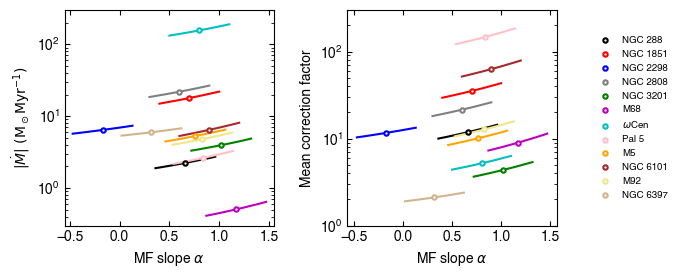

In [46]:
# fig, axs = plt.subplots(1, 3, figsize=(11,3.2), sharex=True, sharey=False)
# plt.subplots_adjust(wspace=0.3)

fig = plt.figure(figsize=(8, 2.8))

outer = gridspec.GridSpec(1, 2, width_ratios=[1, 0.2], wspace=0.1) 
gs0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer[0], wspace=0.35)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec = outer[1], wspace=0.1)

ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs0[1])
ax2 = fig.add_subplot(gs1[0])
axs = [ax0, ax1, ax2]

dlogmdot_alpha_dict = {}

for key, c in zip(gc_stream_list, color_list):
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    mdot_alphas = mdot_alphas_dict[key]
    mean_weight_alphas = mean_weight_alphas_dict[key]

    for y, ax0 in zip([mdot_alphas,mean_weight_alphas], axs[:2]):
        t90 = t90_dict[key]
        dmdot = mdot/np.sqrt(n_obs_dict[key])
        # y = mdot_alphas #/mdot_alphas[15]
        alpha = -gc.loc[key]['MF']
        ax0.scatter(alpha, np.interp(alpha, alphas, y), ec=c, fc='w', lw=1.5, s=10, label=display_name_convert(key), zorder=100)
        dalpha = 0.3
        # ax0.plot(alphas, y, c=c, label=display_name_convert(key), lw=1, alpha=0.5)
        x = np.linspace(alpha-dalpha, alpha+dalpha, 10)
        ax0.plot(x, np.interp(x, alphas, y), c=c, lw=1.5, alpha=1)
        # ax0.plot(alphas, y, c=c, lw=1, alpha=0.2)
        dlogmdot_alpha_dict[key] = 0.5*np.log10(np.interp(alpha+dalpha, alphas, y)/np.interp(alpha-dalpha, alphas, y))
        
    axs[-1].scatter([], [], ec=c, fc='w', lw=1.5, s=10, label=display_name_convert(key))

ax0 = axs[0]

axs[0].set_yscale('log')
axs[0].set_xlabel(r'MF slope $\alpha$')
axs[0].set_ylabel(r'$|\dot{M}|\ ({\rm M_\odot Myr^{-1}})$')
axs[0].set_xlim(-0.55,1.55)
axs[0].set_ylim(3e-1,3e2)
axs[0].tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[1].set_yscale('log')
axs[1].set_xlabel(r'MF slope $\alpha$')
axs[1].set_ylabel(r'Mean correction factor')
axs[1].set_ylim(1e0,3e2)
axs[1].tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[-1].set_axis_off()
axs[-1].legend(fontsize=7, loc='center left', frameon=False)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/alpha_test.pdf', dpi=300, bbox_inches ='tight')
plt.show()

NGC_288
0.15975362718902986
0.256495517903602
NGC_1851
0.1673608740881181
0.2654035616255939
NGC_2298
0.11096111645360915
0.17442891253632814
NGC_2808
0.15816930285870956
0.2525837290452505
NGC_3201
0.16718178097814565
0.2749613185060067
NGC_4590
0.19320837311926523
0.3013121149836758
NGC_5139
0.1576042300865202
0.25902834796728197
Pal_5
0.18011150615031782
0.2812474087123996
NGC_5904
0.16456551645855805
0.2638674867916991
NGC_6101
0.18384581463850666
0.2866116436340648
NGC_6341
0.17136623195423584
0.27142815380150825
NGC_6397
0.10149941124217322
0.1839030704170081


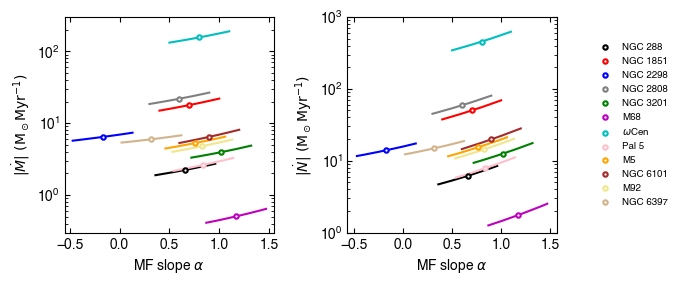

In [47]:
# fig, axs = plt.subplots(1, 3, figsize=(11,3.2), sharex=True, sharey=False)
# plt.subplots_adjust(wspace=0.3)

fig = plt.figure(figsize=(8, 2.8))

outer = gridspec.GridSpec(1, 2, width_ratios=[1, 0.2], wspace=0.1) 
gs0 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer[0], wspace=0.35)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec = outer[1], wspace=0.1)

ax0 = fig.add_subplot(gs0[0])
ax1 = fig.add_subplot(gs0[1])
ax2 = fig.add_subplot(gs1[0])
axs = [ax0, ax1, ax2]

# dlogmdot_alpha_dict = {}

for key, c in zip(gc_stream_list, color_list):
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    mdot_alphas = mdot_alphas_dict[key]
    ndot_alphas = ndot_alphas_dict[key]
    mean_weight_alphas = mean_weight_alphas_dict[key]
    print(key)

    for y, ax0 in zip([mdot_alphas,ndot_alphas], axs[:2]):
        t90 = t90_dict[key]
        dmdot = mdot/np.sqrt(n_obs_dict[key])
        # y = mdot_alphas #/mdot_alphas[15]
        alpha = -gc.loc[key]['MF']
        ax0.scatter(alpha, np.interp(alpha, alphas, y), ec=c, fc='w', lw=1.5, s=10, label=display_name_convert(key), zorder=100)
        dalpha = 0.3
        # ax0.plot(alphas, y, c=c, label=display_name_convert(key), lw=1, alpha=0.5)
        x = np.linspace(alpha-dalpha, alpha+dalpha, 10)
        ax0.plot(x, np.interp(x, alphas, y), c=c, lw=1.5, alpha=1)
        print(np.log10(np.max(np.interp(x, alphas, y))/np.min(np.interp(x, alphas, y))))
        # ax0.plot(alphas, y, c=c, lw=1, alpha=0.2)
        # dlogmdot_alpha_dict[key] = 0.5*np.log10(np.interp(alpha+dalpha, alphas, y)/np.interp(alpha-dalpha, alphas, y))
        
    axs[-1].scatter([], [], ec=c, fc='w', lw=1.5, s=10, label=display_name_convert(key))

ax0 = axs[0]

axs[0].set_yscale('log')
axs[0].set_xlabel(r'MF slope $\alpha$')
axs[0].set_ylabel(r'$|\dot{M}|\ ({\rm M_\odot Myr^{-1}})$')
axs[0].set_xlim(-0.55,1.55)
axs[0].set_ylim(3e-1,3e2)
axs[0].tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[1].set_yscale('log')
axs[1].set_xlabel(r'MF slope $\alpha$')
axs[1].set_ylabel(r'$|\dot{N}|\ ({\rm M_\odot Myr^{-1}})$')
axs[1].set_ylim(1e0,1e3)
axs[1].tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[-1].set_axis_off()
axs[-1].legend(fontsize=7, loc='center left', frameon=False)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/alpha_test_ndot.pdf', dpi=300, bbox_inches ='tight')
plt.show()

**scaling relations**

In [44]:
fit_a = 0.817628; fit_da = 0.155375
fit_b = 0.661537; fit_db = 0.367443
fit_c = 0.538339; fit_dc = 0.554652
fit_d = 0.123844; fit_dd = 0.722501
fit_sig = 0.248595; fit_dsig = 0.0958744


NGC_288 NGC 288
0.05752370937756561 0.07949686167595414

NGC_1851 NGC 1851
0.09711119837887232 0.08364756891293433

NGC_2298 NGC 2298
0.05154127253775816 0.05560533929904384

NGC_2808 NGC 2808
0.04738541279103049 0.07908135289595358

NGC_3201 NGC 3201
0.03370778904405683 0.0839589152280362

NGC_4590 M68
0.056540325643965474 0.097253209377159

NGC_5139 $\omega$Cen
0.010279339290684251 0.07854989365854928

Pal_5 Pal 5
0.047959802402460915 0.09005474682036288

NGC_5904 M5
0.08517215530270575 0.08218605475566336

NGC_6101 NGC 6101
0.12537001801720576 0.09197742533646419

NGC_6341 M92
0.06547235659067634 0.0856279180014214

NGC_6397 NGC 6397
0.021851726868099233 0.04973199740608567


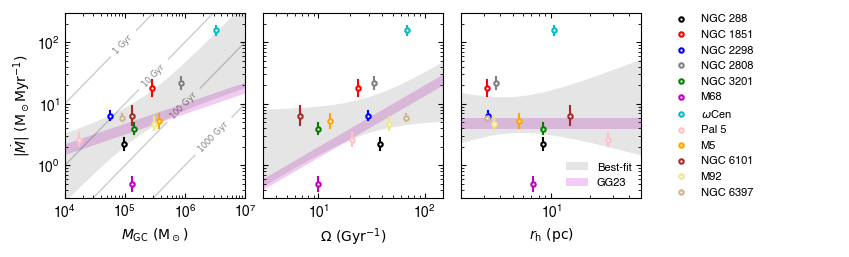

In [48]:
def plot_linear_fit_with_error(ax, xmin, xmax, xmean, ymean, a, da, b, db, sig, dsig, **kwargs):
    
    x = np.linspace(xmin, xmax, 100+1)
    y = a+b*(x-xmean)+ymean
    dy = np.sqrt(sig**2 + da**2 + (db*(x-xmean))**2)
    return ax.fill_between(10**x, 10**(y-dy), 10**(y+dy), **kwargs)

fig, axs = plt.subplots(1, 4, figsize=(10,2.4), sharey=True)
plt.subplots_adjust(wspace=0.1)

for key, c in zip(gc_stream_list, color_list):
    print('')
    print(key, display_name_convert(key))
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    dalpha = 0.3 # gc.loc[key]['DMF']
    dlogmdot_alpha = dalpha/3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    
    y = mdot_dict[key][0]
    yerr = 1/np.sqrt(n_obs_dict[key])
    dlogy = np.sqrt((1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2)
    print(1/np.sqrt(n_obs_dict[key])/np.log(10), dlogmdot_alpha)

    for i, x in enumerate([mgc,Ogc,rgc]):
        axs[i].scatter(x, y, 
            ec=c, fc='w', lw=1.5, s=10, zorder=100)
        axs[i].plot([x]*2, [y*10**dlogy, y*10**-dlogy], 
            c=c, lw=1.5, zorder=99)
        axs[i].set_xscale('log')
    
    # axs[-1].errorbar([], [], yerr=[], marker='o', mec=c, mfc='w', lw=1.5, ecolor=c, ms=4, ls='none', label=display_name_convert(key))
    axs[-1].scatter([], [], ec=c, fc='w', lw=1.5, s=10, label=display_name_convert(key))


x = np.logspace(4,7,31)
for dur in [1e3, 1e4, 1e5, 1e6]:
    axs[0].plot(x, x/dur, c='k', alpha=0.2, lw=1)
    t = axs[0].text(3e3*dur**0.5, 3e3/dur**0.5, r'$%g\ {\rm Gyr}$'%(dur/1e3), va='center', ha='center', alpha=0.5, fontsize=6, rotation=46)
    t.set_bbox(dict(fc='w', alpha=1, ec='none'))
# ax0.plot([1e4, 1e6], [1e0,1e2])
# ax0.plot([1e4, 1e6], [10**(2/3),10**(4/3)])

axs[0].set_xlabel(r'$M_{\rm GC}\ ({\rm M_\odot})$')
axs[0].set_xlim(1e4, 1e7)
plot_linear_fit_with_error(axs[0], 4, 7, np.log10(2e5), 0, fit_a, fit_da, fit_b, fit_db, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98)
x = np.logspace(4,7,2)
axs[0].fill_between(x, 30*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), 45*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97)

axs[1].set_xlabel(r'$\Omega\ ({\rm Gyr^{-1}})$')
axs[1].set_xlim(3e0, 1.5e2)
plot_linear_fit_with_error(axs[1], -1, 3, np.log10(30), 0, fit_a, fit_da, fit_c, fit_dc, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98)
x = np.logspace(-1,3,2)
axs[1].fill_between(x, 30*(np.sqrt(2)*x/320), 45*(np.sqrt(2)*x/320), fc='m', ec='none', alpha=0.2, zorder=97)

# axs[2].set_xlabel(r'$r_{\rm h}/r_{\rm tid}$')
# axs[2].set_xlim(1e-2, 1e0)
axs[2].set_xlabel(r'$r_{\rm h}\ ({\rm pc})$')
axs[2].set_xlim(2e0, 5e1)
plot_linear_fit_with_error(axs[2], 0, 2, np.log10(5), 0, fit_a, fit_da, fit_d, fit_dd, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98, label='Best-fit')
x = np.logspace(0,2,2)
axs[2].fill_between(x, 30*(np.sqrt(2)*0.03/0.32), 45*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97, label='GG23')

for ax0 in axs:
    ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[0].set_yscale('log')
# axs[0].set_ylabel(r'$|\dot{M}|/M_{\rm GC}\ ({\rm Myr^{-1}})$')
# axs[0].set_ylim(5e-6, 1e-3)
axs[0].set_ylabel(r'$|\dot{M}|\ ({\rm M_\odot Myr^{-1}})$')
axs[0].set_ylim(3e-1, 3e2)

axs[2].legend(fontsize=8, loc='lower right', frameon=False)

axs[-1].set_axis_off()
axs[-1].legend(fontsize=8, loc='center left', frameon=False)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/mdot_scaling.pdf', dpi=300, bbox_inches ='tight')
plt.show()


NGC_288 NGC 288
0.05752370937756561 0.07949686167595414

NGC_1851 NGC 1851
0.09711119837887232 0.08364756891293433

NGC_2298 NGC 2298
0.05154127253775816 0.05560533929904384

NGC_2808 NGC 2808
0.04738541279103049 0.07908135289595358

NGC_3201 NGC 3201
0.03370778904405683 0.0839589152280362

NGC_4590 M68
0.056540325643965474 0.097253209377159

NGC_5139 $\omega$Cen
0.010279339290684251 0.07854989365854928

Pal_5 Pal 5
0.047959802402460915 0.09005474682036288

NGC_5904 M5
0.08517215530270575 0.08218605475566336

NGC_6101 NGC 6101
0.12537001801720576 0.09197742533646419

NGC_6341 M92
0.06547235659067634 0.0856279180014214

NGC_6397 NGC 6397
0.021851726868099233 0.04973199740608567


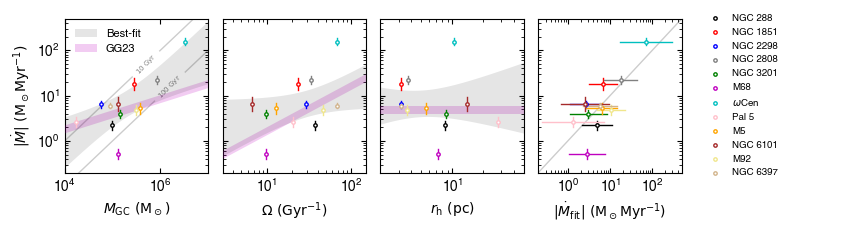

In [242]:
def plot_linear_fit_with_error(ax, xmin, xmax, xmean, ymean, a, da, b, db, sig, dsig, **kwargs):
    
    x = np.linspace(xmin, xmax, 100+1)
    y = a+b*(x-xmean)+ymean
    dy = np.sqrt(sig**2 + da**2 + (db*(x-xmean))**2)
    return ax.fill_between(10**x, 10**(y-dy), 10**(y+dy), **kwargs)
    
fig, axs = plt.subplots(1, 5, figsize=(10,2), sharey=True)
plt.subplots_adjust(wspace=0.1)

for key, c in zip(gc_stream_list, color_list):
    print('')
    print(key, display_name_convert(key))
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    dalpha = 0.3 # gc.loc[key]['DMF']
    dlogmdot_alpha = dalpha/3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    xgc = 10**fit_a * (mgc/2e5)**fit_b * (Ogc/30)**fit_c * (rgc/5)**fit_d
    logxgc = np.log10(xgc)
    dlogxgc = np.sqrt(fit_da**2 + (np.log10(mgc/2e5)*fit_db)**2 + (np.log10(Ogc/30)*fit_dc)**2 + (np.log10(rgc/5)*fit_dd)**2 + fit_sig**2)
    
    y = mdot_dict[key][0]
    yerr = 1/np.sqrt(n_obs_dict[key])
    dlogy = np.sqrt((1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2)
    print(1/np.sqrt(n_obs_dict[key])/np.log(10), dlogmdot_alpha)

    for i, x in enumerate([mgc,Ogc,rgc,xgc]):
        axs[i].scatter(x, y, 
            ec=c, fc='w', lw=1, s=6, zorder=100)
        axs[i].plot([x]*2, [y*10**dlogy, y*10**-dlogy], 
            c=c, lw=1, zorder=99)
        axs[i].set_xscale('log')

    axs[3].plot([10**(logxgc-dlogxgc),10**(logxgc+dlogxgc)], [y,y], c=c, lw=1, zorder=99)
    
    # axs[-1].errorbar([], [], yerr=[], marker='o', mec=c, mfc='w', lw=1.5, ecolor=c, ms=4, ls='none', label=display_name_convert(key))
    axs[-1].scatter([], [], ec=c, fc='w', lw=1, s=6, label=display_name_convert(key))


x = np.logspace(4,7,31)
for dur in [1e4, 1e5]:
    axs[0].plot(x, x/dur, c='k', alpha=0.2, lw=1)
    t = axs[0].text(5e3*dur**0.5, 5e3/dur**0.5, r'$%g\ {\rm Gyr}$'%(dur/1e3), va='center', ha='center', alpha=0.5, fontsize=5, rotation=46)
    t.set_bbox(dict(fc='w', alpha=1, ec='none'))
# ax0.plot([1e4, 1e6], [1e0,1e2])
# ax0.plot([1e4, 1e6], [10**(2/3),10**(4/3)])

axs[0].set_xlabel(r'$M_{\rm GC}\ ({\rm M_\odot})$')
axs[0].set_xlim(1e4, 1e7)
plot_linear_fit_with_error(axs[0], 4, 7, np.log10(2e5), 0, fit_a, fit_da, fit_b, fit_db, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98, label='Best-fit')
x = np.logspace(4,7,2)
axs[0].fill_between(x, 30*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), 45*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97, label='GG23')

axs[1].set_xlabel(r'$\Omega\ ({\rm Gyr^{-1}})$')
axs[1].set_xlim(3e0, 1.5e2)
plot_linear_fit_with_error(axs[1], -1, 3, np.log10(30), 0, fit_a, fit_da, fit_c, fit_dc, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98, label='Best-fit')
x = np.logspace(-1,3,2)
axs[1].fill_between(x, 30*(np.sqrt(2)*x/320), 45*(np.sqrt(2)*x/320), fc='m', ec='none', alpha=0.2, zorder=97, label='GG23')

# axs[2].set_xlabel(r'$r_{\rm h}/r_{\rm tid}$')
# axs[2].set_xlim(1e-2, 1e0)
axs[2].set_xlabel(r'$r_{\rm h}\ ({\rm pc})$')
axs[2].set_xlim(2e0, 5e1)
plot_linear_fit_with_error(axs[2], 0, 2, np.log10(5), 0, fit_a, fit_da, fit_d, fit_dd, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98, label='Best-fit')
x = np.logspace(0,2,2)
axs[2].fill_between(x, 30*(np.sqrt(2)*0.03/0.32), 45*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97, label='GG23')

axs[3].set_xlabel(r'$|\dot{M}_{\rm fit}|\ ({\rm M_\odot Myr^{-1}})$')
axs[3].set_xlim(2e-1, 5e2)
x = np.logspace(-1,3,2)
axs[3].plot(x, x, c='k', alpha=0.2, lw=1)

for ax0 in axs:
    ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

axs[0].set_yscale('log')
# axs[0].set_ylabel(r'$|\dot{M}|/M_{\rm GC}\ ({\rm Myr^{-1}})$')
# axs[0].set_ylim(5e-6, 1e-3)
axs[0].set_ylabel(r'$|\dot{M}|\ ({\rm M_\odot Myr^{-1}})$')
axs[0].set_ylim(2e-1, 5e2)

axs[0].legend(fontsize=8, loc='upper left', frameon=False)

axs[-1].set_axis_off()
axs[-1].legend(fontsize=7, loc='center left', frameon=False)

fig.align_xlabels(axs)

# plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/mdot_scaling.pdf', dpi=300, bbox_inches ='tight')
plt.show()


NGC_288 NGC 288
0.05752370937756561 0.07949686167595414

NGC_1851 NGC 1851
0.09711119837887232 0.08364756891293433

NGC_2298 NGC 2298
0.05154127253775816 0.05560533929904384

NGC_2808 NGC 2808
0.04738541279103049 0.07908135289595358

NGC_3201 NGC 3201
0.03370778904405683 0.0839589152280362

NGC_4590 M68
0.056540325643965474 0.097253209377159

NGC_5139 $\omega$Cen
0.010279339290684251 0.07854989365854928

Pal_5 Pal 5
0.047959802402460915 0.09005474682036288

NGC_5904 M5
0.08517215530270575 0.08218605475566336

NGC_6101 NGC 6101
0.12537001801720576 0.09197742533646419

NGC_6341 M92
0.06547235659067634 0.0856279180014214

NGC_6397 NGC 6397
0.021851726868099233 0.04973199740608567


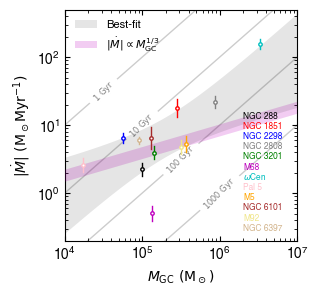

In [64]:
def plot_linear_fit_with_error(ax, xmin, xmax, xmean, ymean, a, da, b, db, sig, dsig, **kwargs):
    
    x = np.linspace(xmin, xmax, 100+1)
    y = a+b*(x-xmean)+ymean
    dy = np.sqrt(sig**2 + da**2 + (db*(x-xmean))**2)
    return ax.fill_between(10**x, 10**(y-dy), 10**(y+dy), **kwargs)
    
fig, ax0 = plt.subplots(1, 1, figsize=(3,3), sharey=True)
# plt.subplots_adjust(wspace=0.1)

for i, (key, c) in enumerate(zip(gc_stream_list, color_list)):
    print('')
    print(key, display_name_convert(key))
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    dalpha = 0.3 # gc.loc[key]['DMF']
    dlogmdot_alpha = dalpha/3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    xgc = 10**fit_a * (mgc/2e5)**fit_b * (Ogc/30)**fit_c * (rgc/5)**fit_d
    logxgc = np.log10(xgc)
    dlogxgc = np.sqrt(fit_da**2 + (np.log10(mgc/2e5)*fit_db)**2 + (np.log10(Ogc/30)*fit_dc)**2 + (np.log10(rgc/5)*fit_dd)**2 + fit_sig**2)
    
    y = mdot_dict[key][0]
    yerr = 1/np.sqrt(n_obs_dict[key])
    dlogy = np.sqrt((1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2)
    print(1/np.sqrt(n_obs_dict[key])/np.log(10), dlogmdot_alpha)

    x = mgc
    
    ax0.scatter(x, y, 
        ec=c, fc='w', lw=1, s=6, zorder=100)
    ax0.plot([x]*2, [y*10**dlogy, y*10**-dlogy], 
        c=c, lw=1, zorder=99)
    ax0.set_xscale('log')
    ax0.text(10**6.3, 10**(1.1-i*0.15), display_name_convert(key), color=c, fontsize=6, zorder=100)
    
    # ax0.scatter([], [], ec=c, fc='w', lw=1, s=6, label=display_name_convert(key))


x = np.logspace(4,7,31)
for dur in [1e3, 1e4, 1e5, 1e6]:
    ax0.plot(x, x/dur, c='k', alpha=0.2, lw=1)
    t = ax0.text(1e3*dur**0.5, 1e3/dur**0.5, r'$%g\ {\rm Gyr}$'%(dur/1e3), va='center', ha='center', alpha=0.5, fontsize=6, rotation=46)
    t.set_bbox(dict(fc='w', alpha=1, ec='none'))

ax0.set_xlabel(r'$M_{\rm GC}\ ({\rm M_\odot})$')
ax0.set_xlim(1e4, 1e7)
plot_linear_fit_with_error(ax0, 4, 7, np.log10(2e5), 0, fit_a, fit_da, fit_b, fit_db, fit_sig, fit_dsig, fc='k', ec='none', alpha=0.1, zorder=98, label='Best-fit')
x = np.logspace(4,7,2)
# ax0.fill_between(x, 30*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), 45*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97, label='GG23')
ax0.fill_between(x, 30*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), 45*(x/2e5)**(1/3)*(np.sqrt(2)*0.03/0.32), fc='m', ec='none', alpha=0.2, zorder=97, label=r'$|\dot{M}|\propto M_{\rm GC}^{1/3}$')

ax0.tick_params(which='both', direction='in', bottom=True, top=True, left=True, right=True)

ax0.set_yscale('log')
ax0.set_ylabel(r'$|\dot{M}|\ ({\rm M_\odot Myr^{-1}})$')
ax0.set_ylim(2e-1, 5e2)

ax0.legend(fontsize=8, loc='upper left', frameon=False)

# plt.savefig('/Users/ybchen/Downloads/mdot_scaling.pdf', dpi=300, bbox_inches ='tight')
plt.show()

In [265]:

for key, c in zip(gc_stream_list, color_list):
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    alpha = gc.loc[key]['MF']
    dgc = gc.loc[key]['Rsun']
    mdot = mdot_dict[key][0]
    mdot_broken = mdot_broken_dict[key][0]
    ndot = mdot / mstar_mean_dict[key]
    t90 = t90_dict[key]
    dur = dur_dict[key]
    ddur = ddur_dict[key]
    dalpha = 0.3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    dlogy = np.sqrt((1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2)
    dphi1_max = dphi1_max_dict[key]
    # dmdot = mdot/np.sqrt(n_obs_dict[key])
    # print(r'%s & %.2f & %.1f & %.1f & %.2f & $%.2f^{+%.2f}_{-%.2f}$ & %.2f \\'%(
    #     display_name_convert(key), mgc/1e5, Ogc, rgc, -alpha, mdot, mdot*(10**dlogy-1), mdot*(1-10**-dlogy), t90))
    print(r'%s & %.2f & %.1f & %.1f & %.2f & %.1f & $%.1f \pm %.1f$ & $%.1f \pm %.1f$ & %.1f & $%.2f \pm %.2f$ \\'%(
        display_name_convert(key), mgc/1e5, Ogc, rgc, -alpha, dgc, mdot, mdot*np.log(10)*dlogy, ndot, ndot*np.log(10)*dlogy, dphi1_max, dur, ddur))

NGC 288 & 0.98 & 37.6 & 8.6 & 0.66 & 9.0 & $2.2 \pm 0.5$ & $6.2 \pm 1.4$ & 4.6 & $0.70 \pm 0.37$ \\
NGC 1851 & 2.81 & 23.4 & 3.2 & 0.70 & 11.9 & $17.9 \pm 5.3$ & $50.0 \pm 14.8$ & 4.9 & $0.45 \pm 0.29$ \\
NGC 2298 & 0.57 & 29.4 & 3.2 & -0.17 & 9.8 & $6.4 \pm 1.1$ & $14.0 \pm 2.4$ & 4.9 & $0.22 \pm 0.15$ \\
NGC 2808 & 8.69 & 33.7 & 3.8 & 0.60 & 10.1 & $21.9 \pm 4.6$ & $59.0 \pm 12.5$ & 5.1 & $0.13 \pm 0.11$ \\
NGC 3201 & 1.41 & 9.9 & 8.7 & 1.02 & 4.7 & $3.9 \pm 0.8$ & $12.6 \pm 2.6$ & 89.5 & $1.07 \pm 0.39$ \\
M68 & 1.32 & 9.8 & 7.3 & 1.17 & 10.4 & $0.5 \pm 0.1$ & $1.7 \pm 0.5$ & 86.1 & $2.34 \pm 0.82$ \\
$\omega$Cen & 33.40 & 68.5 & 10.4 & 0.80 & 5.4 & $156.0 \pm 28.4$ & $453.8 \pm 82.8$ & 26.6 & $0.42 \pm 0.31$ \\
Pal 5 & 0.17 & 20.6 & 27.6 & 0.84 & 23.6 & $2.7 \pm 0.6$ & $8.1 \pm 1.9$ & 16.9 & $6.20 \pm 1.69$ \\
M5 & 3.68 & 12.8 & 5.6 & 0.76 & 7.5 & $5.3 \pm 1.4$ & $15.3 \pm 4.2$ & 40.1 & $0.64 \pm 0.24$ \\
NGC 6101 & 1.30 & 6.7 & 13.9 & 0.90 & 14.4 & $6.4 \pm 2.3$ & $19.8 \pm 7.1$ &

In [245]:
from astropy.units import cds
for key, c in zip(gc_stream_list, color_list):
    # print(mdot_dict[key][0])
    mgc = 10**gc.loc[key]['logm']
    Ogc = 2*np.pi/T_dict[key]
    rgc = gc.loc[key]['rh,m'] #/ gc.loc[key]['rt']
    alpha = gc.loc[key]['MF']
    dgc = gc.loc[key]['Rsun']
    mdot = mdot_dict[key][0]
    t90 = t90_dict[key]
    dur = dur_dict[key]
    ddur = ddur_dict[key]
    dalpha = 0.3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    dlogy = np.sqrt((1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2)
    dphi1_max = dphi1_max_dict[key]
    rtid = gc.loc[key]['rt']

    physical_diffusion_rate = (dphi1_max * np.pi/180 * dgc * u.kpc / (dur*u.Gyr)).to_value(u.km/u.s)
    vesc_at_rtid = np.sqrt(2 * cds.G * mgc * u.Msun / (rtid * u.pc)).to_value(u.km/u.s)
    print(display_name_convert(key), ': physical_diffusion_rate = %.2f km/s, vesc_at_rtid = %.2f km/s, ratio = %.2f'%(physical_diffusion_rate, vesc_at_rtid, physical_diffusion_rate/vesc_at_rtid))

NGC 288 : physical_diffusion_rate = 1.01 km/s, vesc_at_rtid = 2.98 km/s, ratio = 0.34
NGC 1851 : physical_diffusion_rate = 2.21 km/s, vesc_at_rtid = 4.42 km/s, ratio = 0.50
NGC 2298 : physical_diffusion_rate = 3.73 km/s, vesc_at_rtid = 2.59 km/s, ratio = 1.44
NGC 2808 : physical_diffusion_rate = 6.88 km/s, vesc_at_rtid = 6.82 km/s, ratio = 1.01
NGC 3201 : physical_diffusion_rate = 6.76 km/s, vesc_at_rtid = 3.84 km/s, ratio = 1.76
M68 : physical_diffusion_rate = 6.53 km/s, vesc_at_rtid = 3.81 km/s, ratio = 1.72
$\omega$Cen : physical_diffusion_rate = 5.83 km/s, vesc_at_rtid = 11.74 km/s, ratio = 0.50
Pal 5 : physical_diffusion_rate = 1.10 km/s, vesc_at_rtid = 1.72 km/s, ratio = 0.64
M5 : physical_diffusion_rate = 7.98 km/s, vesc_at_rtid = 6.24 km/s, ratio = 1.28
NGC 6101 : physical_diffusion_rate = 4.27 km/s, vesc_at_rtid = 3.55 km/s, ratio = 1.20
M92 : physical_diffusion_rate = 2.83 km/s, vesc_at_rtid = 4.87 km/s, ratio = 0.58
NGC 6397 : physical_diffusion_rate = 3.20 km/s, vesc_at_rti

In [246]:
# Theoretical estimate from BT08

for key, c in zip(gc_stream_list, color_list):
    mgc = 10**gc.loc[key]['logm'] # in Msun
    rgc = gc.loc[key]['rh,m'] # in pc
    # mstar = 0.5 # in Msun
    mstar = mstar_mean_dict[key] # in Msun
    Nstar = mgc / mstar
    trh = 780 / np.log(0.2*Nstar) * (mstar/1)**-1 * (mgc/1e5)**0.5 * (rgc/1)**1.5 # in Myr

    mdot_bt08 = mgc / (20*trh)
    mdot = mdot_dict[key][0]

    print(display_name_convert(key), rgc, trh, mdot/mdot_bt08)


NGC 288 8.56 4902.638511228853 2.2281416259884206
NGC 1851 3.16 1718.5555998522977 2.183499598586574
NGC 2298 3.2 726.6473266346269 1.6320521158044259
NGC 2808 3.75 3449.9825738833306 1.7361743251224082
NGC 3201 8.68 6604.889689026373 3.6992854074755783
M68 7.27 5313.485987205752 0.40623403682027104
$\omega$Cen 10.42 30467.55632954698 28.45425759128776
Pal 5 27.63 15227.555626288611 46.74489104262006
M5 5.6 4673.782763125214 1.3427328818806246
NGC 6101 13.87 12510.110559479179 12.403374722845834
M92 3.59 2324.6478467604848 0.7125492189058781
NGC 6397 3.16 968.0515466772287 1.285724719040038


In [247]:
# rh / rtid

for key, c in zip(gc_stream_list, color_list):
    rgc = gc.loc[key]['rh,m'] # in pc
    rtid = gc.loc[key]['rt'] # in pc

    print(display_name_convert(key), rgc/rtid)

NGC 288 0.08995376208490963
NGC 1851 0.025547740318538282
NGC 2298 0.04376966215292026
NGC 2808 0.02336011960381237
NGC 3201 0.1054165654602866
M68 0.09287174246295349
$\omega$Cen 0.049952061361457335
Pal 5 0.5556002413030364
M5 0.06888916225858038
NGC 6101 0.15593029792017987
M92 0.03176991150442478
NGC 6397 0.06365834004834811


In [248]:
# **fit parameters**

manual_scatter = 0.3

def neg_log_gaussian_likelihood(p, logmdot, logm, logOmega, logr, dlogmdot):
    a = p[0]
    b = p[1]
    c = p[2]
    d = p[3]
    sig = p[4]
    sigi2 = sig**2 + dlogmdot**2
    return np.sum(np.log(sigi2) + (logmdot-a-b*logm-c*logOmega-d*logr)**2/sigi2)
    
def linear_fit_maxlike_boot(logmdot, logm, logOmega, logr, dlogmdot, size=100):
    data = np.column_stack((logmdot, logm, logOmega, logr, dlogmdot))
    rng = np.random.default_rng(0)
    data_boot = data[rng.integers(0, len(logmdot), (size, len(logmdot)))]
    
    a_list = np.zeros(size)
    b_list = np.zeros(size)
    c_list = np.zeros(size)
    d_list = np.zeros(size)
    sig_list = np.zeros(size)
    
    for i, d in enumerate(data_boot):
        bnds = ((-2, 4), (-5, 5), (-5, 5), (-5, 5), (0, None))
        o = minimize(neg_log_gaussian_likelihood, [0.,0.,1.,0.,0.], 
            args=(d[:,0],d[:,1],d[:,2],d[:,3],d[:,4]), bounds=bnds)
        a_list[i] = o.x[0]
        b_list[i] = o.x[1]
        c_list[i] = o.x[2]
        d_list[i] = o.x[3]
        sig_list[i] = o.x[4]
        
    return a_list, b_list, c_list, d_list, sig_list
    
logmdot = []
logm = []
logOmega = []
logr = []
dlogmdot = []
for key in gc_stream_list:
    # if key == 'NGC_5139':
    #     continue
    logmdot.append(np.log10(mdot_dict[key][0]))
    logm.append(gc.loc[key]['logm'])
    logOmega.append(np.log10(2*np.pi / T_dict[key]))
    logr.append(np.log10(gc.loc[key]['rh,m'])) #/ gc.loc[key]['rt']))
    dalpha = 0.3 # gc.loc[key]['DMF']
    dlogmdot_alpha = dalpha/3
    dlogmdot_alpha = dlogmdot_alpha_dict[key]
    dlogmdot.append(np.sqrt( (1/np.sqrt(n_obs_dict[key])/np.log(10))**2 + dlogmdot_alpha**2 ))
    
    
logmdot = np.array(logmdot)
logm = np.array(logm)
logOmega = np.array(logOmega)
logr = np.array(logr)
dlogmdot = np.array(dlogmdot)

a, b, c, d, sig = linear_fit_maxlike_boot(logmdot, logm-np.log10(2e5), logOmega-np.log10(30), logr-np.log10(5), dlogmdot, 1000)

In [249]:
# symbols are messed up. historical mess

print('logMref = %g; da = %g'%(np.mean(a), np.std(a)))
print('Mref = %g + %g - %g'%(10**np.mean(a), 10**np.mean(a)*(10**np.std(a)-1), 10**np.mean(a)*(1-10**-np.std(a))))
print('a = %g; da = %g'%(np.mean(b), np.std(b)))
print('b = %g; db = %g'%(np.mean(c), np.std(c)))
print('c = %g; dc = %g'%(np.mean(d), np.std(d)))
print('sig = %g; dsig = %g'%(np.mean(sig), np.std(sig)))

print('')

print('fit_a = %g; fit_da = %g'%(np.mean(a), np.std(a)))
print('fit_b = %g; fit_db = %g'%(np.mean(b), np.std(b)))
print('fit_c = %g; fit_dc = %g'%(np.mean(c), np.std(c)))
print('fit_d = %g; fit_dd = %g'%(np.mean(d), np.std(d)))
print('fit_sig = %g; fit_dsig = %g'%(np.mean(sig), np.std(sig)))

logMref = 0.817628; da = 0.155375
Mref = 6.57094 + 2.82634 - 1.97629
a = 0.661537; da = 0.367443
b = 0.538339; db = 0.554652
c = 0.123844; dc = 0.722501
sig = 0.248595; dsig = 0.0958744

fit_a = 0.817628; fit_da = 0.155375
fit_b = 0.661537; fit_db = 0.367443
fit_c = 0.538339; fit_dc = 0.554652
fit_d = 0.123844; fit_dd = 0.722501
fit_sig = 0.248595; fit_dsig = 0.0958744


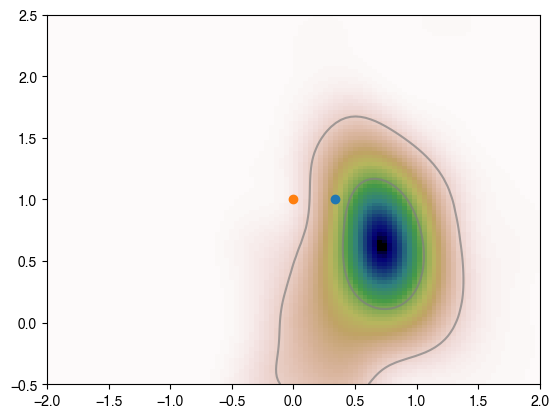

In [250]:
xmin = -2
xmax = 2
ymin = -0.5
ymax = 2.5

hx = 0.2
hy = 0.2
y_scale = hy/hx

X, Y = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
positions = np.vstack([X.ravel(), Y.ravel()])
values = np.vstack([b, c/y_scale])
kernel = gaussian_kde(values, bw_method=hx)
kernel.covariance = np.eye(values.shape[0]) * hx**2
kernel.cho_cov = linalg.cholesky(np.eye(values.shape[0]), lower=True) * hx
Z = np.reshape(kernel(positions).T, X.shape)

sorted_kde_vals = np.sort(Z.ravel())
total_kde_val = np.sum(sorted_kde_vals)
cdf = np.cumsum(sorted_kde_vals) / total_kde_val
levels = [sorted_kde_vals[np.argmax(cdf >= p)] for p in [1-0.954**2, 1-0.683**2]]
plt.contour(X, Y, Z, levels=levels, colors='gray', alpha=0.7)

plt.imshow(np.rot90(Z), cmap=plt.cm.gist_earth_r, extent=[xmin, xmax, ymin, ymax])
# plt.scatter(b, c)

plt.scatter(1/3,1)
plt.scatter(0,1)

### Estimate the mass of Pal 5 from CFHT

**Method 1: cut a different region in CMD as background**

**Disliked by Eric**

mass of a segment = 25908.1 Msun
mass of a segment = 10943.4 Msun
total mass from CFHT = 36851.5 Msun


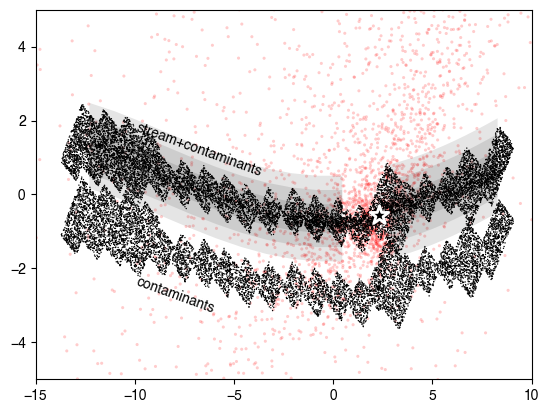

In [251]:
key = 'Pal_5'
mass_func = kroupa
yaxis = 'phi2'
distance_mode = 'mock'

stream = ds_i19[key]
stream_bg = ds_i19_bg[key]

# plot mock stars and prog GC
x = mockstream.phi1
x_prog = mockstream.prog_phi1
if yaxis == 'phi2hat':
    y = mockstream.phi2hat
elif yaxis == 'phi2':
    y = mockstream.phi2
else:
    raise AttributeError
plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
plt.scatter(x, y, s=1, ec='none', fc='k')
plt.scatter(x_bg, y_bg-2, s=1, ec='none', fc='k')
plt.scatter(x_prog, y_prog, s=200, ec='w', fc='k', marker='*', lw=2)

# detect segments
segs = detect_segs(stream)

# distance and distance modulus

if distance_mode == 'prog':
    dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
    dist_bg = np.full_like(stream_bg.phi1, fill_value=stream_bg.c_prog.distance.to_value('kpc'))
elif distance_mode == 'mock':
    pd = pd_dict[key]     
    dist = np.poly1d(pd)(stream.phi1)
    dist_bg = np.poly1d(pd)(stream_bg.phi1)
dist_mod = 5*(np.log10(dist)+2)
dist_bg_mod = 5*(np.log10(dist_bg)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
masses_bg = calc_mass(stream_bg.mag - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min_bg = calc_mass(r_limit - dist_bg_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

# weights of stars to correct for missing stars
weights = mass_func(0, mass_max) / mass_func(mass_min, mass_max)
weights_bg = mass_func(0, mass_max) / mass_func(mass_min_bg, mass_max)

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):
    # plot the Gaussian width
    for factor in [1,2,3]:
        if yaxis == 'phi2hat':
            x = seg
            y = np.zeros_like(seg)
        elif yaxis == 'phi2':
            x = np.linspace(seg[0], seg[1], 11)
            y = stream.fit_poly(x)
        plt.fill_between(x, y-factor*width, y+factor*width, fc='k', ec='none', alpha=0.1)

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
    mask_bg = (stream_bg.phi1>seg[0]) & (stream_bg.phi1<seg[1])
        
    print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    # print('mass of a segment = %g Msun'%(np.sum(masses[mask]*weights[mask])))
    # print('mass of a segment = %g Msun'%(np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])))
    mtot += np.sum(masses[mask]*weights[mask])-np.sum(masses_bg[mask_bg]*weights_bg[mask_bg])

print('total mass from CFHT = %g Msun'%mtot)

plt.xlim(-15,10)
plt.ylim(-5,5)

plt.text(-10, 0.5, 'stream+contaminants', rotation=-20)
plt.text(-10, -3.2, 'contaminants', rotation=-20)

plt.show()

**Method 2: cut the outer region as background**

**first, estimate area using Monte-Carlo method**

In [252]:
# all data
all_i19 = sd.StreamDataset('Ibata+19', None, data['RAJ2000'], data['DEJ2000'], None, None, 
        None, data['r0mag'], data['g0mag']-data['r0mag'], None, None, None, None, None, gc.loc['Pal_5'])
all_i19.construct_greatcircle_coord(GreatCircle=ds_i24['Pal_5'].GreatCircle)
all_i19.construct_polynomial_coord(p=ds_i24['Pal_5'].p, deg=4)

In [253]:
def get_area(xsize, ysize, bg_start=0.5, above=True, all=False, left=-np.inf, right=np.inf):
    mask = (all_i19.phi1>=left) & (all_i19.phi1<=right) 
    if all:
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), np.arange(-1.5,1.5+ysize,ysize)])[0].astype(int)
    elif above:
        mask &= (all_i19.phi2hat>=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), np.arange(bg_start,1.5+ysize,ysize)])[0].astype(int)
    else:
        mask &= (all_i19.phi2hat<=bg_start)
        x = all_i19.phi1[mask]
        y = all_i19.phi2hat[mask]
        counts = binned_statistic_2d(x, y, None, 'count', bins=[np.arange(-14,10+xsize,xsize), -np.arange(bg_start,1.5+ysize,ysize)[::-1]])[0].astype(int)

    return np.sum(counts>0) * xsize * ysize


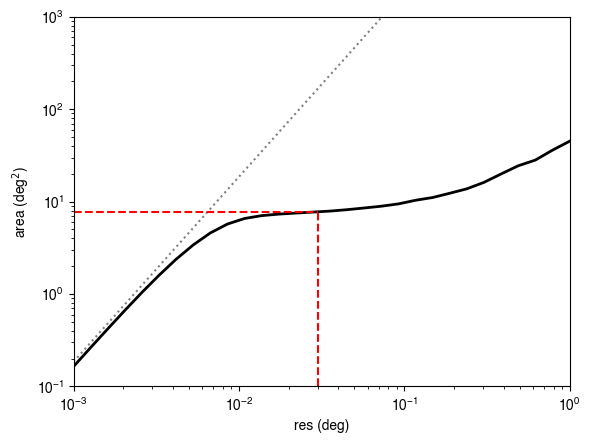

In [254]:
bg_start=0.5

res = np.logspace(-3,0,30)
areas = [get_area(r, r, bg_start) + get_area(r, r, bg_start, above=False) for r in res]

plt.plot(res, areas, c='k', lw=2)

plt.plot(res, len(all_i19.phi1[(all_i19.phi2hat>=bg_start)|(all_i19.phi2hat<=-bg_start)])*res*res, c='gray', ls=':')

annotate_r = 0.03
annotate_area = get_area(annotate_r, annotate_r, bg_start) + get_area(annotate_r, annotate_r, bg_start, above=False)
plt.hlines(annotate_area, 1e-3, annotate_r, color='r', ls='--')
plt.vlines(annotate_r, 1e-1, annotate_area, color='r', ls='--')

plt.xlabel('res (deg)')
plt.ylabel(r'area (deg$^2$)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e-3, 1e0)
plt.ylim(1e-1, 1e3)

plt.show()

In [255]:
key = 'Pal_5'
bg_start = 0.5
sizex = 0.03
sizey = 0.03

area_all = get_area(sizex, sizey, all=True)
area_above = get_area(sizex, sizey, bg_start=bg_start)
mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
print(len(ds_i19[key].phi1[mask_above])*area_all/area_above)

area_below = get_area(sizex, sizey, bg_start=bg_start, above=False)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
print(len(ds_i19[key].phi1[mask_below])*area_all/area_below)

mask_out = mask_above | mask_below
area_out = area_above + area_below
print(len(ds_i19[key].phi1[mask_out])*area_all/area_out)


10675.089992800575
10552.239496742304
10611.640519842189


mass of a segment = 8472.86 Msun
mass loss rate of segment = 3.00669 Msun/Myr
mass of a segment = 1604.32 Msun
mass loss rate of segment = 1.59159 Msun/Myr
total mass from CFHT = 10077.2 Msun
mass loss rate from CFHT = 2.63387 Msun/Myr


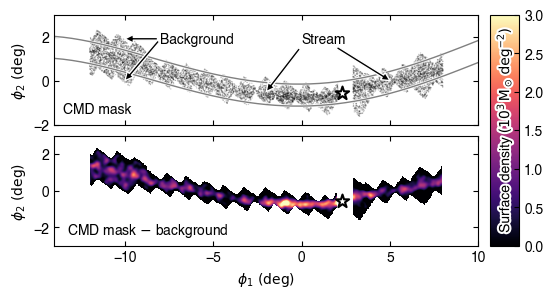

In [256]:
fig = plt.figure(figsize=(6, 3))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 0.07], height_ratios=[1, 1], wspace=0.05, hspace=0.1)

########## scatter plot ##########

ax0 = fig.add_subplot(gs[0, 0])

key = 'Pal_5'
mass_func = kroupa
mass_func = lambda mmin, mmax: power_law_broken_imf(mmin, mmax, -1.5)
mass_func = lambda mmin, mmax: power_law_imf(mmin, mmax, gc.loc[key]['MF'])
bg_start = 0.5
sizex = 0.03
sizey = 0.03
yaxis = 'phi2'
distance_mode = 'mock'
mfmin = 0.08

stream = ds_i19[key]
mockstream = mockstreams[key]

# calcualte number loss rate
ndot = 2 * nhalf / t_tot.to_value('Myr')

# detect segments
# segs = detect_segs(stream, percentiles=[0,100])

segs = segs_dict[key]
segs[0][0] = -12
segs[1][1] = 8

# # plot mock stars and prog GC
# x = mockstream.phi1
# x_prog = mockstream.prog_phi1
# if yaxis == 'phi2hat':
#     y = mockstream.phi2hat
# elif yaxis == 'phi2':
#     y = mockstream.phi2
# else:
#     raise AttributeError
# plt.scatter(x, y, s=5, ec='none', fc='r', alpha=0.2)

# plot observed stars and prog GC
x = stream.phi1
x_bg = stream_bg.phi1
x_prog = stream.prog_phi1
if yaxis == 'phi2hat':
    y = stream.phi2hat
    y_bg = stream_bg.phi2hat
    y_prog = stream.prog_phi2hat
elif yaxis == 'phi2':
    y = stream.phi2
    y_bg = stream_bg.phi2
    y_prog = stream.prog_phi2
else:
    raise AttributeError
    
for seg in segs:
    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])
    ax0.scatter(x[mask], y[mask], s=1, ec='none', fc='k', alpha=0.2, rasterized=True)
    
ax0.scatter(x_prog, y_prog, s=100, ec='k', fc='w', marker='*', lw=1.5)

# plot background boundaries
if yaxis == 'phi2hat':
    ax0.hlines([bg_start, -bg_start], -14, 10, color='gray', ls='--')
elif yaxis == 'phi2':
    x = np.linspace(-14, 10, 49)
    y = stream.fit_poly(x)
    ax0.plot(x, y+bg_start, c='w', lw=2)
    ax0.plot(x, y+bg_start, c='gray', lw=1)
    ax0.plot(x, y-bg_start, c='w', lw=2)
    ax0.plot(x, y-bg_start, c='gray', lw=1)

# distance and distance modulus
dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
if distance_mode == 'prog':
    dist = np.full_like(stream.phi1, fill_value=stream.c_prog.distance.to_value('kpc'))
elif distance_mode == 'mock':
    dist = np.poly1d(pd_dict[key])(stream.phi1)
dist_mod = 5*(np.log10(dist)+2)

# select isochrone
iso_idx = select_iso(stream.color, stream.mag - dist_mod, iso_cfht_list, "g'mag", "r'mag", "r'mag")

# calculate mass of stars, minimum observable mass, maximum survived mass
masses = calc_mass(stream.mag - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_min = calc_mass(r_limit - dist_mod, iso_cfht_list[iso_idx], "r'mag")
mass_max = np.max(iso_cfht_list[iso_idx]['Mini'][iso_cfht_list[iso_idx]['label']<=3])

mask_above = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat>=bg_start)&(ds_i19[key].phi2hat<=1.5)
mask_below = (ds_i19[key].phi1>-14)&(ds_i19[key].phi1<=10)&(ds_i19[key].phi2hat<=-bg_start)&(ds_i19[key].phi2hat>=-1.5)
mask_bg = mask_above | mask_below

# weights of stars to correct for missing stars
weights = mass_func(mfmin, mass_max) / mass_func(mass_min, mass_max)

# background density
density_bg = np.sum(masses[mask_bg]*weights[mask_bg]) / area_out

# print('total mass = %g Msun'%(np.sum(masses*weights)-np.sum(masses_bg*weights_bg)))

mtot = 0
select_weight_sum = 0

# now, look at individual segments
gaus_widths = calc_selection_function(stream, segs)
for seg, width in zip(segs, gaus_widths):

    mask = (stream.phi1>seg[0]) & (stream.phi1<seg[1])

    area_seg = get_area(sizex, sizey, all=True, left=seg[0], right=seg[1])

    mseg = np.sum(masses[mask]*weights[mask])-density_bg*area_seg
    print('mass of a segment = %g Msun'%mseg)
    
    mtot += mseg
    
    mask = (mockstream.phi1>=seg[0]) & (mockstream.phi1<seg[1])
    select_weights = np.ones_like(mockstream.phi2hat[mask]) # uniform selection function
    # select_weights = np.exp(0.5 * mockstream.phi2hat[mask]**2 * (mockwidth**-2 - width**-2))
    mdot = ndot * mseg / np.sum(select_weights)
    select_weight_sum += np.sum(select_weights)

    print('mass loss rate of segment = %g Msun/Myr'%mdot)

print('total mass from CFHT = %g Msun'%mtot)
print('mass loss rate from CFHT = %g Msun/Myr'%(ndot*mtot/select_weight_sum))

# ax0.text(-8, 0.5, 'background', rotation=-20)
ax0.annotate('Background', xy=(-10, 1.9), xytext=(-8, 1.9), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1), zorder=100)
ax0.annotate('', xy=(-10, 0), xytext=(-8.1, 1.8), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))
ax0.annotate('Stream', xy=(-2, -0.5), xytext=(0, 1.9), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1), zorder=100)
ax0.annotate('', xy=(5, 0), xytext=(2, 1.5), va='center', ha='left',
    arrowprops=dict(fc='k', ec='w', width=2, headwidth=6, headlength=6, lw=1))

ax0.text(0.02, 0.08, r'CMD mask', transform=ax0.transAxes, va='bottom', ha='left')

ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')
ax0.set_xlim(-14,10)
ax0.set_ylim(-2,3)
ax0.set_xticklabels([])

ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

########## kde plot ##########

ax0 = fig.add_subplot(gs[1, 0])

xsize = 0.05
ysize = 0.05

ax0.scatter(x_prog, y_prog, s=100, ec='k', fc='w', marker='*', lw=1.5)

xbins = np.arange(-14,10+xsize,xsize)
ybins = np.arange(-2,3+ysize,ysize)
xcenter = (xbins[1:] + xbins[:-1]) / 2
ycenter = (ybins[1:] + ybins[:-1]) / 2

counts = binned_statistic_2d(all_i19.phi1, all_i19.phi2, None, 'count', bins=[xbins, ybins])[0].astype(int)


factor_kde = 1

x = stream.phi1 / factor_kde
y = stream.phi2
data = np.row_stack([x,y])
kde = gaussian_kde(data, weights=masses*weights, bw_method=0.1)
kde.covariance = np.eye(data.shape[0]) * kde.factor**2
kde.cho_cov = linalg.cholesky(np.eye(data.shape[0]), lower=True)* kde.factor

# density = binned_statistic_2d(x, y, masses*weights, 'sum', bins=[xbins, ybins])[0] / xsize / ysize

xx, yy = np.meshgrid(xcenter, ycenter, indexing='ij')
points = np.row_stack([xx.flatten()/factor_kde, yy.flatten()])
Z = np.reshape(kde(points), xx.shape) / factor_kde

Zhere = Z * np.sum(masses*weights)
Zhere -= density_bg
Zhere[counts==0] = np.nan

mask = np.ones_like(Zhere, dtype=bool)
for seg in segs:
    mask[(xx>=seg[0]) & (xx<=seg[1])] = False
    
Zhere[mask] = np.nan

cax0 = ax0.imshow(np.rot90(Zhere)/1e3, extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], vmin=0, vmax=3, cmap='magma')

ax0.text(0.03, 0.06, r'CMD mask $-$ background', transform=ax0.transAxes, va='bottom', ha='left')

ax0.set_aspect('auto')

ax0.set_xlabel(r'$\phi_1\ ({\rm deg})$')
ax0.set_ylabel(r'$\phi_2\ ({\rm deg})$')

ax0.set_xlim(-14,10)
ax0.set_ylim(-3,3)

ax0.tick_params(direction='in', bottom=True, top=True, left=True, right=True)

cbar_ax = fig.add_subplot(gs[:, 1])  # This spans both rows
fig.colorbar(cax0, cax=cbar_ax)
cbar_ax.tick_params(direction='in')

txt = cbar_ax.text(0.5, 0.5, r'Surface density $\rm (10^3\,M_\odot\,deg^{-2})$', rotation=90, transform=cbar_ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

plt.savefig('/Users/ybchen/Documents/GC-stream-mass-loss/figures/cfht_background_substract.pdf', dpi=300, bbox_inches ='tight')
plt.show()

In [257]:
stream.p

array([-4.18331378e-05,  1.38639446e-04,  2.17945572e-02,  8.19709409e-03,
       -6.59403273e-01])

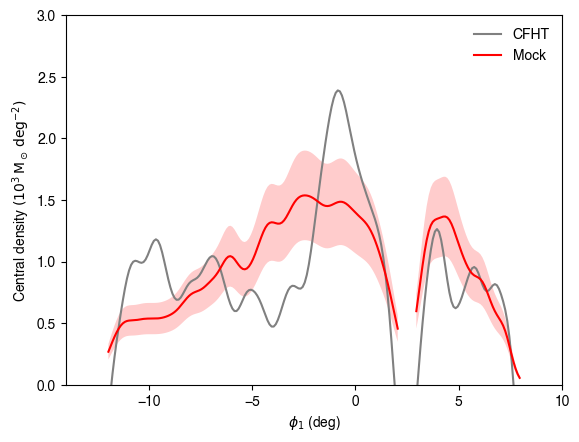

In [258]:

segs = segs_dict[key]

factor_kde = 5

mask = np.zeros_like(stream.phi1, dtype=bool)
for seg in segs:
    mask[(stream.phi1>=seg[0]) & (stream.phi1<=seg[1])] = True
    
x = stream.phi1[mask] / factor_kde
y = stream.phi2[mask]
data = np.row_stack([x,y])
kde = gaussian_kde(data, weights=masses[mask]*weights[mask], bw_method=0.1)
kde.covariance = np.eye(data.shape[0]) * kde.factor**2
kde.cho_cov = linalg.cholesky(np.eye(data.shape[0]), lower=True)* kde.factor

# density = binned_statistic_2d(x, y, masses*weights, 'sum', bins=[xbins, ybins])[0] / xsize / ysize

xbins = np.arange(-14,10,0.1)
xx = (xbins[1:] + xbins[:-1]) / 2
yy = kde(np.row_stack([xx / factor_kde, stream.fit_poly(xx)])) * np.sum(masses[mask]*weights[mask]) / factor_kde - density_bg
yy /= 1e3

mask = np.ones_like(yy, dtype=bool)
for seg in segs:
    mask[(xx>=seg[0]) & (xx<=seg[1])] = False

yy[mask] = np.nan
    
plt.plot(xx,yy, c='gray', label='CFHT')


mask = np.zeros_like(mockstream.phi1, dtype=bool)
for seg in segs:
    mask[(mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1])] = True

x = mockstream.phi1[mask] / factor_kde
y = mockstream.phi2[mask]
data = np.row_stack([x,y])
kde = gaussian_kde(data, bw_method=0.1)
kde.covariance = np.eye(data.shape[0]) * kde.factor**2
kde.cho_cov = linalg.cholesky(np.eye(data.shape[0]), lower=True)* kde.factor

# density = binned_statistic_2d(x, y, masses*weights, 'sum', bins=[xbins, ybins])[0] / xsize / ysize

xbins = np.arange(-14,10,0.1)
xx = (xbins[1:] + xbins[:-1]) / 2
yy = kde(np.row_stack([xx / factor_kde, stream.fit_poly(xx)])) * 2.62 * len(x) / factor_kde
yy /= 1e3

mask = np.ones_like(yy, dtype=bool)
for seg in segs:
    mask[(xx>=seg[0]) & (xx<=seg[1])] = False

yy[mask] = np.nan
    
plt.plot(xx,yy, c='r', label='Mock')
# plt.plot(xx,yy*(1+0.62/2.62))
# plt.plot(xx,yy*(1-0.62/2.62))
plt.fill_between(xx, yy*(1-0.62/2.62), yy*(1+0.62/2.62), alpha=0.2, fc='r', ec='none')

# plt.vlines(segs, 0,3000)


plt.ylim(0,3)


plt.xlim(-14,10)
# plt.ylim(-3,3)

plt.xlabel(r'$\phi_1$ (deg)')
plt.ylabel(r'Central density $\rm (10^3\, M_\odot\,deg^{-2})$')

plt.legend(loc='upper right', frameon=False)
plt.show()

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0., 18., 20., 18., 17., 19., 11.,
        23., 26., 11., 24., 18., 16., 24., 18., 19., 21., 24., 20., 24.,
        19., 20., 23., 24., 21., 18., 17., 16., 23., 16., 14., 16., 16.,
        17., 21., 24., 13., 21., 13., 18., 22., 20., 21., 20., 11., 26.,
        22., 14., 25., 21., 23., 25., 35., 18.,  9., 31.,  8., 29., 24.,
        17., 29., 21., 28., 23., 20., 20., 22., 15., 14., 21., 22., 15.,
        14., 20., 23., 24., 24., 20., 27., 19., 16., 17., 21., 16., 20.,
        15., 10., 21., 23., 22., 29., 23., 10., 24., 20., 26., 20., 29.,
        20., 14., 26.,  9., 22., 24., 26., 15., 20., 12., 22., 12., 22.,
        30., 18., 13., 25., 24., 22., 27., 22., 18., 22., 17., 22., 15.,
        21., 21., 27., 14., 14., 14., 30., 24., 20., 17., 13., 15., 20.,
        29., 21., 20., 21., 13.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        25., 32., 19., 23., 15., 16., 29., 17., 24.

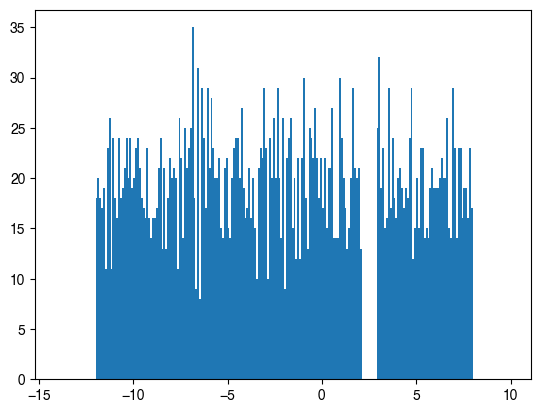

In [259]:
mask = np.zeros_like(stream.phi1, dtype=bool)
for seg in segs:
    mask[(stream.phi1>=seg[0]) & (stream.phi1<=seg[1])] = True
    
x = stream.phi1[mask]


mask = np.zeros_like(mockstream.phi1, dtype=bool)
for seg in segs:
    mask[(mockstream.phi1>=seg[0]) & (mockstream.phi1<=seg[1])] = True

x = mockstream.phi1[mask]

plt.hist(x, bins=xbins)